# Part 0: Load in Libraries

In [68]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import localcider
from localcider.sequenceParameters import SequenceParameters
import re
import math
import scipy
from scipy.stats import ks_2samp
from matplotlib.patches import Rectangle
import pathlib
from matplotlib import font_manager
from matplotlib.pyplot import gcf
import scipy.stats as stats
!pip install Fitter
from fitter import Fitter, get_common_distributions, get_distributions



# Setup the fonts
fonts_path = pathlib.Path.home().joinpath('fonts') # i.e. `~/fonts` (update as needed)
font_filename = 'ARIAL.TTF'
font_path = fonts_path.joinpath(font_filename)
print(font_path)

font_manager.fontManager.addfont(str(font_path))
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42

COLOR_MAP = dict()
COLOR_MAP['A']         = '#8c8c8c'
COLOR_MAP['CHNQST']    = '#077a15'
COLOR_MAP['DE']        = '#e23a36'
COLOR_MAP['FWY']       = '#f58220'
COLOR_MAP['G']         = '#86bd8d'
COLOR_MAP['ILMV']      = '#231f20'
COLOR_MAP['KR']        = '#1725c2'
COLOR_MAP['P']         = '#c25fc9'


# Using the global color map, we convert the colormap of amino acid
# groups, to a map against individual amino acids. This
# serves as our internal color map which is used for styling.
aacolor_map=dict()
for amino_acids in COLOR_MAP:
    for amino_acid in amino_acids:
        aacolor_map[amino_acid] = COLOR_MAP[amino_acids]

Defaulting to user installation because normal site-packages is not writeable
/home/research/kiersten.ruff/fonts/ARIAL.TTF


# Part 1: Load in IDRome Data

## 1.1 - Load in All Sapiens Disordered Stretches >=30

In [60]:
# uses nardini_env
import pandas as pd
import seaborn as sbn

speciesname='sapiens'

# Gene names table
mapdf=pd.read_table('data/sapiens_uniprot_gene_name.tsv')
accsmap=mapdf['Uniprot'].tolist()
genesmap=mapdf['Gene'].tolist()

myseqs=[]
fullaccswnums=[]
goodidxs=[]
badidxs=[]
fullaccs=[]
mygenes=[]
seqlens=[]

myfile = open('data/idrs_min_length_30/'+speciesname, 'r')
Lines = myfile.readlines()

count=0
for line in Lines:
    count=count+1
    fullline=line.split(" ")
    tmpseq=fullline[3]
    tmpacc=fullline[0]
    currseq=tmpseq.strip('\n')
    
    if len(currseq)>=30 and "X" not in currseq and "U" not in currseq and "Z" not in currseq and "J" not in currseq and "B" not in currseq and "O" not in currseq:
        myseqs.append(currseq)
        fullaccswnums.append(tmpacc)
        goodidxs.append(count)
        seqlens.append(len(currseq))
        tmp=tmpacc.split("_")
        fullaccs.append(tmp[0])
        if tmp[0] in accsmap:
            currgidx=accsmap.index(tmp[0])
            mygenes.append(genesmap[currgidx]+' IDR'+tmp[1])
        else:
            mygenes.append(tmp[0]+' IDR'+tmp[1])
    else:
        badidxs.append(count)
        
print(len(myseqs))
print(count)
print(len(goodidxs))
print(badidxs)
#print(mygenes)

24508
24535
24508
[337, 338, 5387, 7965, 8270, 8860, 9309, 13434, 18343, 20894, 20895, 20896, 20897, 20898, 20900, 20901, 20902, 20903, 20904, 20905, 20906, 20907, 20908, 20909, 21628, 22016, 23960]


## 1.2 - Load NARDINI data for all sapiens IDRs gte 30

In [61]:
zvec=np.load('data/'+speciesname+'_full_idrome_gte_30_nardini.npy')
#print(zvec)

# check vector
idx=fullaccswnums.index('Q8NFD5_1')
print(myseqs[idx])
print(zvec[idx])
print(zvec[idx][21])
print(len(zvec))

myfeat=['pol-pol','pol-hyd','pol-pos','pol-neg','pol-aro','pol-ala','pol-pro','pol-gly','hyd-hyd','hyd-pos','hyd-neg','hyd-aro','hyd-ala','hyd-pro','hyd-gly','pos-pos','pos-neg','pos-aro','pos-ala','pos-pro','pos-gly','neg-neg','neg-aro','neg-ala','neg-pro','neg-gly','aro-aro','aro-ala','aro-pro','aro-gly','ala-ala','ala-pro','ala-gly','pro-pro','pro-gly','gly-gly','Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','Y Patch','RG Frac']

myfeatnardini=['pol-pol','pol-hyd','pol-pos','pol-neg','pol-aro','pol-ala','pol-pro','pol-gly','hyd-hyd','hyd-pos','hyd-neg','hyd-aro','hyd-ala','hyd-pro','hyd-gly','pos-pos','pos-neg','pos-aro','pos-ala','pos-pro','pos-gly','neg-neg','neg-aro','neg-ala','neg-pro','neg-gly','aro-aro','aro-ala','aro-pro','aro-gly','ala-ala','ala-pro','ala-gly','pro-pro','pro-gly','gly-gly']

print(len(myfeat))

MAHNAGAAAAAGTHSAKSGGSEAALKEGGSAAALSSSSSSSAAAAAASSSSSSGPGSAMETGLLPNHKLKTVGEAPAAPPHQQHHHHHHAHHHHHHAHHLHHHHALQQQLNQFQQQQQQQQQQQQQQQQQQHPISNNNSLGGAGGGAPQPGPDMEQPQHGGAKDSAAGGQADPPGPPLLSKPGDEDDAPPKMGEPAGGRYEHPGLGALGTQQPPVAVPGGGGGPAAVPEFNNYYGSAAPASGGPGGRAGPCFDQHGGQQSPGMGMMHSASAAAAGAPGSMDPLQNSHEGYPNSQCNHYPGYSRPGAGGGGGGGGGGGGGSGGGGGGGGAGAGGAGAGAVAAAAAAAAAAAGGGGGGGYGGSSAGYGVLSSPRQQGGGMMMGPGGGGAASLSKAAAGSAAGGFQRFAGQNQHPSGATPTLNQLLTSPSPMMRSYGGSYPEYSSPSAPPPPPSQPQSQAAAAGAAAGGQQAAAGMGLGKD
[10.59108354  0.          0.          0.          0.         11.65941098
  0.         14.39589484  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  5.76110201  0.          7.43819192  0.          0.          7.20103122]
0.0
24508
90


## 1.3 - Get all compositional sequence features the sapiens IDRome

[0.07741329870246792, 0.008538805724799583, 0.05127727736370751, 0.09008763614629162, 0.014270327223274142, 0.08332631606660568, 0.023213564275380197, 0.01785675831127527, 0.06098073687889461, 0.05867819723550179, 0.016164841817388885, 0.030837123165538154, 0.11307352429649098, 0.05451395702245792, 0.06577801431451794, 0.12502566544640797, 0.05722109753347246, 0.03588171932609476, 0.005580771458323423, 0.010280367691109179, 0.12675875119341254, 0.14136491350999913, 0.38267652923466194, 0.20599481539272863, 0.030131466372706743, 0.05493351039784072, 0.1841411803139005, 0.3811971889999026, 0.26812366470341165, -0.01460616231658658, 3.4110708906101537, 0.8019110880466948, 7.44443247900792, 0.4044778171527079, 0.013228570102474755, 2.8313019279589203e-06, 0.00565433376114803, 0.024103760059206916, 1.1039838114785175e-05, 0.023394616782112673, 0.0014528601714245697, 1.625241407649792e-05, 0.012782162346973061, 0.0011648168919885275, 9.498442431682362e-05, 0.0008614367526042599, 0.0403653516

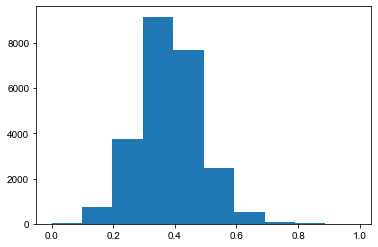

In [65]:

numInt=2 # Number of allowable interruption residues
minBlockLen=4 # Must have at least minBlockLen lysines in the block

aas='ACDEFGHIKLMNPQRSTVY' # For pathces - no W patch in proteome so this is removed
#aas='CEK'

filename=[speciesname]

for fname in filename:
    myfile = open('data/idrs_min_length_30/'+fname, 'r')
    Lines = myfile.readlines()
    fracA=[]
    fracC=[]
    fracD=[]
    fracE=[]
    fracF=[]
    fracG=[]
    fracH=[]
    fracI=[]
    fracK=[]
    fracL=[]
    fracM=[]
    fracN=[]
    fracP=[]
    fracQ=[]
    fracR=[]
    fracS=[]
    fracT=[]
    fracV=[]
    fracW=[]
    fracY=[]
    fracpos=[]
    fracneg=[]
    fracpol=[]
    fracali=[]
    fracaro=[]
    fracRtoK=[]
    fracEtoD=[]
    fracexp=[]
    fcr=[]
    ncpr=[]
    mhydro=[]
    dispro=[]
    isopoi=[]
    ppii=[]
    fracpatch=[[] for _ in range(len(aas))]
    rgpatch=[]
    
    for line in Lines:
        fullline=line.split(" ")
        tmpseq=fullline[3]
        currseq=tmpseq.strip('\n')

        if len(currseq)>=30 and "X" not in currseq and "U" not in currseq and "Z" not in currseq and "J" not in currseq and "B" not in currseq and "O" not in currseq:
            SeqOb = SequenceParameters(currseq)
            slen=SeqOb.get_length()
            aafrac=SeqOb.get_amino_acid_fractions()
            
            fracexp.append(SeqOb.get_fraction_expanding())
            fcr.append(SeqOb.get_FCR())
            ncpr.append(SeqOb.get_NCPR())
            mhydro.append(SeqOb.get_mean_hydropathy())
            dispro.append(SeqOb.get_fraction_disorder_promoting())
            isopoi.append(SeqOb.get_isoelectric_point())
            ppii.append(SeqOb.get_PPII_propensity(mode='hilser'))

            ## AA Fractions
            fracA.append(aafrac['A'])
            fracC.append(aafrac['C'])
            fracD.append(aafrac['D'])
            fracE.append(aafrac['E'])
            fracF.append(aafrac['F'])
            fracG.append(aafrac['G'])
            fracH.append(aafrac['H'])
            fracI.append(aafrac['I'])
            fracK.append(aafrac['K'])
            fracL.append(aafrac['L'])
            fracM.append(aafrac['M'])
            fracN.append(aafrac['N'])
            fracP.append(aafrac['P'])
            fracQ.append(aafrac['Q'])
            fracR.append(aafrac['R'])
            fracS.append(aafrac['S'])
            fracT.append(aafrac['T'])
            fracV.append(aafrac['V'])
            fracW.append(aafrac['W'])
            fracY.append(aafrac['Y'])

            ## AA Physicochemical properties
            fracpos.append(aafrac['K']+aafrac['R'])
            fracneg.append(aafrac['D']+aafrac['E'])
            fracpol.append(aafrac['Q']+aafrac['N']+aafrac['S']+aafrac['T']+aafrac['G']+aafrac['C']+aafrac['H'])
            fracali.append(aafrac['A']+aafrac['L']+aafrac['M']+aafrac['I']+aafrac['V'])
            fracaro.append(aafrac['F']+aafrac['W']+aafrac['Y'])
            
            ## AA ratios
            fracRtoK.append(np.log10(((slen*aafrac['R'])+1)/((slen*aafrac['K'])+1)))
            fracEtoD.append(np.log10(((slen*aafrac['E'])+1)/((slen*aafrac['D'])+1)))
            
            ## Fraction of sequence containing patches
            counta=-1
            for a in aas:
                counta=counta+1
                justKs='0'*len(currseq) # Set string of zeros

                pos=[i for i, ltr in enumerate(currseq) if ltr == a] # Find positions of the residue of interest

                # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
                pos2=pos
                for p in range(0,len(pos)-1):
                    tdi=pos[p+1]-pos[p]
                    if tdi > 1 and tdi<=numInt+1:
                        myt=list(range(pos[p]+1,pos[p+1]))
                        for item in myt:
                            pos2.append(item)


                # For positions make those 1 in string of zeros   
                justKs = list(justKs)
                for p in pos2:
                    justKs[p]='1'
                justKs = ''.join(justKs)


                the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
                idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

                numpatches=0
                count=-1
                patchescombined=''
                for o in the_ones:
                    count=count+1
                    myrange=idx_ones[count] # Get indices for each consecutive strength
                    subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
                    pos3=[i for i, ltr in enumerate(subseq) if ltr == a] # Get positions of the actual residue of interest in this subseq
                    # If the number of the actual residue of interest is greater than or equal to minBlockLen add to the number of patches and string patches together in string
                    if len(pos3)>=minBlockLen:
                        numpatches=numpatches+1
                        patchescombined+=subseq

                fracpatch[counta].append(len(patchescombined)/len(currseq))
                
            ## Fraction of sequence in RG stretch
            justKs='0'*len(currseq) # Set string of zeros
            pos=[i for i, ltr in enumerate(currseq) if ltr == 'R' or ltr == 'G'] # Find positions of Rs and Gs

            # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
            pos2=pos
            for p in range(0,len(pos)-1):
                tdi=pos[p+1]-pos[p]
                if tdi > 1 and tdi<=numInt+1:
                    myt=list(range(pos[p]+1,pos[p+1]))
                    for item in myt:
                        pos2.append(item)

            # For positions make those 1 in string of zeros             
            justKs = list(justKs)
            for p in pos2:
                justKs[p]='1'
            justKs = ''.join(justKs)

            the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
            idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

            count=-1
            patchescombined=''
            for o in the_ones:
                count=count+1
                myrange=idx_ones[count] # Get indices for each consecutive strength
                subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
                pos3=subseq.count('RG')
                #print(subseq)
                if pos3>=2:
                    patchescombined+=subseq

            rgpatch.append(len(patchescombined)/len(currseq))

    varlist=[fracA, fracC, fracD, fracE, fracF, fracG, fracH, fracI, fracK, fracL, fracM, fracN, fracP, fracQ, fracR, fracS, fracT, fracV, fracW, fracY, fracpos, fracneg, fracpol, fracali, fracaro, fracRtoK, fracEtoD, fracexp, fcr, ncpr, mhydro, dispro, isopoi, ppii]
    
    meanvals_sapiens=[np.mean(fracA), np.mean(fracC), np.mean(fracD), np.mean(fracE), np.mean(fracF), np.mean(fracG), np.mean(fracH), np.mean(fracI), np.mean(fracK), np.mean(fracL), np.mean(fracM), np.mean(fracN), np.mean(fracP), np.mean(fracQ), np.mean(fracR), np.mean(fracS), np.mean(fracT), np.mean(fracV), np.mean(fracW), np.mean(fracY), np.mean(fracpos), np.mean(fracneg), np.mean(fracpol), np.mean(fracali), np.mean(fracaro), np.mean(fracRtoK), np.mean(fracEtoD), np.mean(fracexp), np.mean(fcr), np.mean(ncpr), np.mean(mhydro), np.mean(dispro), np.mean(isopoi), np.mean(ppii)]
    stdvals_sapiens=[np.std(fracA), np.std(fracC), np.std(fracD), np.std(fracE), np.std(fracF), np.std(fracG), np.std(fracH), np.std(fracI), np.std(fracK), np.std(fracL), np.std(fracM), np.std(fracN), np.std(fracP), np.std(fracQ), np.std(fracR), np.std(fracS), np.std(fracT), np.std(fracV), np.std(fracW), np.std(fracY), np.std(fracpos), np.std(fracneg), np.std(fracpol), np.std(fracali), np.std(fracaro), np.std(fracRtoK), np.std(fracEtoD), np.std(fracexp), np.std(fcr), np.std(ncpr), np.std(mhydro), np.std(dispro), np.std(isopoi), np.std(ppii)]
    
    for a in fracpatch:
        meanvals_sapiens.append(np.mean(a))
        stdvals_sapiens.append(np.std(a))
        varlist.append(a)
    
    meanvals_sapiens.append(np.mean(rgpatch))
    stdvals_sapiens.append(np.std(rgpatch))
    varlist.append(rgpatch)
    

    print(meanvals_sapiens)
    print(stdvals_sapiens)
    print(len(rgpatch))
    print(len(fracA))
    print(np.mean(rgpatch))
    print(np.std(rgpatch))
    
    
    plt.hist(fracpol)

## 1.4 - Add non-patterning features to feature vector

In [66]:
# Remove the number of the IDR in the full human IDRome accession list
fullacc=fullaccs
    
typeall=['pol','hyd','pos','neg','aro','ala','pro','gly']
zvecaa=np.zeros((len(myseqs),int(len(typeall)+(len(typeall)*(len(typeall)-1))/2)+34+len(aas)+1))
tmp=zvec

countseq=-1
for currseq in myseqs:
    countseq=countseq+1
    tmpacc=fullacc[countseq]
    SeqOb = SequenceParameters(currseq)
    
    slen=SeqOb.get_length()
    aafrac=SeqOb.get_amino_acid_fractions()
    
    fracexp=SeqOb.get_fraction_expanding()
    fcr=SeqOb.get_FCR()
    ncpr=SeqOb.get_NCPR()
    mhydro=SeqOb.get_mean_hydropathy()
    dispro=SeqOb.get_fraction_disorder_promoting()
    isopoi=SeqOb.get_isoelectric_point()
    ppii=SeqOb.get_PPII_propensity(mode='hilser')
    
    tmpseq=[]
    
    ## AA Fractions
    afA=np.array((aafrac['A']-meanvals_sapiens[0])/stdvals_sapiens[0])
    tmpseq.append(afA)
    afC=np.array((aafrac['C']-meanvals_sapiens[1])/stdvals_sapiens[1])
    tmpseq.append(afC)
    afD=np.array((aafrac['D']-meanvals_sapiens[2])/stdvals_sapiens[2])
    tmpseq.append(afD)
    afE=np.array((aafrac['E']-meanvals_sapiens[3])/stdvals_sapiens[3])
    tmpseq.append(afE)
    afF=np.array((aafrac['F']-meanvals_sapiens[4])/stdvals_sapiens[4])
    tmpseq.append(afF)
    afG=np.array((aafrac['G']-meanvals_sapiens[5])/stdvals_sapiens[5])
    tmpseq.append(afG)
    afH=np.array((aafrac['H']-meanvals_sapiens[6])/stdvals_sapiens[6])
    tmpseq.append(afH)
    afI=np.array((aafrac['I']-meanvals_sapiens[7])/stdvals_sapiens[7])
    tmpseq.append(afI)
    afK=np.array((aafrac['K']-meanvals_sapiens[8])/stdvals_sapiens[8])
    tmpseq.append(afK)
    afL=np.array((aafrac['L']-meanvals_sapiens[9])/stdvals_sapiens[9])
    tmpseq.append(afL)
    afM=np.array((aafrac['M']-meanvals_sapiens[10])/stdvals_sapiens[10])
    tmpseq.append(afM)
    afN=np.array((aafrac['N']-meanvals_sapiens[11])/stdvals_sapiens[11])
    tmpseq.append(afN)
    afP=np.array((aafrac['P']-meanvals_sapiens[12])/stdvals_sapiens[12])
    tmpseq.append(afP)
    afQ=np.array((aafrac['Q']-meanvals_sapiens[13])/stdvals_sapiens[13])
    tmpseq.append(afQ)
    afR=np.array((aafrac['R']-meanvals_sapiens[14])/stdvals_sapiens[14])
    tmpseq.append(afR)
    afS=np.array((aafrac['S']-meanvals_sapiens[15])/stdvals_sapiens[15])
    tmpseq.append(afS)
    afT=np.array((aafrac['T']-meanvals_sapiens[16])/stdvals_sapiens[16])
    tmpseq.append(afT)
    afV=np.array((aafrac['V']-meanvals_sapiens[17])/stdvals_sapiens[17])
    tmpseq.append(afV)
    afW=np.array((aafrac['W']-meanvals_sapiens[18])/stdvals_sapiens[18])
    tmpseq.append(afW)
    afY=np.array((aafrac['Y']-meanvals_sapiens[19])/stdvals_sapiens[19])
    tmpseq.append(afY)
    
    ## AA Physicochemical properties
    afpos=np.array(((aafrac['K']+aafrac['R'])-meanvals_sapiens[20])/stdvals_sapiens[20])
    tmpseq.append(afpos)
    afneg=np.array(((aafrac['D']+aafrac['E'])-meanvals_sapiens[21])/stdvals_sapiens[21])
    tmpseq.append(afneg)
    afpol=np.array(((aafrac['Q']+aafrac['N']+aafrac['S']+aafrac['T']+aafrac['G']+aafrac['C']+aafrac['H'])-meanvals_sapiens[22])/stdvals_sapiens[22])
    tmpseq.append(afpol)
    afali=np.array(((aafrac['A']+aafrac['L']+aafrac['M']+aafrac['I']+aafrac['V'])-meanvals_sapiens[23])/stdvals_sapiens[23])
    tmpseq.append(afali)
    afaro=np.array(((aafrac['F']+aafrac['W']+aafrac['Y'])-meanvals_sapiens[24])/stdvals_sapiens[24])
    tmpseq.append(afaro)
    
    ## AA ratios
    afRK=np.array((np.log10(((slen*aafrac['R'])+1)/((slen*aafrac['K'])+1))-meanvals_sapiens[25])/stdvals_sapiens[25])
    tmpseq.append(afRK)
    afED=np.array((np.log10(((slen*aafrac['E'])+1)/((slen*aafrac['D'])+1))-meanvals_sapiens[26])/stdvals_sapiens[26])
    tmpseq.append(afED)
    
    ## Charge measures
    afexp=np.array((fracexp-meanvals_sapiens[27])/stdvals_sapiens[27])
    tmpseq.append(afexp)
    afcr=np.array((fcr-meanvals_sapiens[28])/stdvals_sapiens[28])
    tmpseq.append(afcr)
    ancpr=np.array((ncpr-meanvals_sapiens[29])/stdvals_sapiens[29])
    tmpseq.append(ancpr)
    
    ## Miscellaneous measures
    amhydro=np.array((mhydro-meanvals_sapiens[30])/stdvals_sapiens[30])
    tmpseq.append(amhydro)
    adispro=np.array((dispro-meanvals_sapiens[31])/stdvals_sapiens[31])
    tmpseq.append(adispro)
    aisopoi=np.array((isopoi-meanvals_sapiens[32])/stdvals_sapiens[32])
    tmpseq.append(aisopoi)
    appii=np.array((ppii-meanvals_sapiens[33])/stdvals_sapiens[33])
    tmpseq.append(appii)
    
    ## Fraction of sequence containing patches
    counta=-1
    for a in aas:
        counta=counta+1
        justKs='0'*len(currseq) # Set string of zeros

        pos=[i for i, ltr in enumerate(currseq) if ltr == a] # Find positions of the residue of interest

        # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
        pos2=pos
        for p in range(0,len(pos)-1):
            tdi=pos[p+1]-pos[p]
            if tdi > 1 and tdi<=numInt+1:
                myt=list(range(pos[p]+1,pos[p+1]))
                for item in myt:
                    pos2.append(item)


        # For positions make those 1 in string of zeros   
        justKs = list(justKs)
        for p in pos2:
            justKs[p]='1'
        justKs = ''.join(justKs)


        the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
        idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

        numpatches=0
        count=-1
        patchescombined=''
        for o in the_ones:
            count=count+1
            myrange=idx_ones[count] # Get indices for each consecutive strength
            subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
            pos3=[i for i, ltr in enumerate(subseq) if ltr == a] # Get positions of the actual residue of interest in this subseq
            # If the number of the actual residue of interest is greater than or equal to minBlockLen add to the number of patches and string patches together in string
            if len(pos3)>=minBlockLen:
                numpatches=numpatches+1
                patchescombined+=subseq

        afracpatch=(len(patchescombined)/len(currseq))
        afracp=np.array((afracpatch-meanvals_sapiens[33+counta+1])/stdvals_sapiens[33+counta+1])
        tmpseq.append(afracp)
    
    ## Fraction of sequence in RG stretch
    justKs='0'*len(currseq) # Set string of zeros
    pos=[i for i, ltr in enumerate(currseq) if ltr == 'R' or ltr == 'G'] # Find positions of Rs and Gs

    # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
    pos2=pos
    for p in range(0,len(pos)-1):
        tdi=pos[p+1]-pos[p]
        if tdi > 1 and tdi<=numInt+1:
            myt=list(range(pos[p]+1,pos[p+1]))
            for item in myt:
                pos2.append(item)

    # For positions make those 1 in string of zeros             
    justKs = list(justKs)
    for p in pos2:
        justKs[p]='1'
    justKs = ''.join(justKs)

    the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
    idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

    count=-1
    patchescombined=''
    for o in the_ones:
        count=count+1
        myrange=idx_ones[count] # Get indices for each consecutive strength
        subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
        pos3=subseq.count('RG')
        if pos3>=2:
            patchescombined+=subseq

    arg=(len(patchescombined)/len(currseq))
    argp=np.array((arg-meanvals_sapiens[33+counta+2])/stdvals_sapiens[33+counta+2])
    tmpseq.append(argp)
    
    zvecaa[countseq,:]=np.append(tmp[countseq,:],tmpseq)
    #print(np.append(zvecaa[countseq,:],afA))
    #print((zvecaa))
    
    
print(np.shape(zvecaa))

# check vector
idx=fullaccswnums.index('Q8NFD5_1')
print(myseqs[idx])
print(zvecaa[idx])


(24508, 90)
MAHNAGAAAAAGTHSAKSGGSEAALKEGGSAAALSSSSSSSAAAAAASSSSSSGPGSAMETGLLPNHKLKTVGEAPAAPPHQQHHHHHHAHHHHHHAHHLHHHHALQQQLNQFQQQQQQQQQQQQQQQQQQHPISNNNSLGGAGGGAPQPGPDMEQPQHGGAKDSAAGGQADPPGPPLLSKPGDEDDAPPKMGEPAGGRYEHPGLGALGTQQPPVAVPGGGGGPAAVPEFNNYYGSAAPASGGPGGRAGPCFDQHGGQQSPGMGMMHSASAAAAGAPGSMDPLQNSHEGYPNSQCNHYPGYSRPGAGGGGGGGGGGGGGSGGGGGGGGAGAGGAGAGAVAAAAAAAAAAAGGGGGGGYGGSSAGYGVLSSPRQQGGGMMMGPGGGGAASLSKAAAGSAAGGFQRFAGQNQHPSGATPTLNQLLTSPSPMMRSYGGSYPEYSSPSAPPPPPSQPQSQAAAAGAAAGGQQAAAGMGLGKD
[ 1.05910835e+01  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.16594110e+01  0.00000000e+00  1.43958948e+01
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  5.76110201e+00  0.00

## 1.5 - Test compositional feature distributions

Fitting 4 distributions: 100%|██████████| 4/4 [00:00<00:00,  6.59it/s]


         sumsquare_error          aic            bic  kl_div  ks_statistic  \
lognorm       105.946592   417.292045 -133386.814200     inf      0.039664   
norm          176.892051  1753.107403 -120834.008768     inf      0.083829   
expon         336.975446   200.669408 -105039.328180     inf      0.154497   
gamma         699.834946    58.522590  -87117.930798     inf      0.435510   

             ks_pvalue  
lognorm   6.473696e-34  
norm     5.107109e-150  
expon     0.000000e+00  
gamma     0.000000e+00  
Index(['sumsquare_error', 'aic', 'bic', 'kl_div', 'ks_statistic', 'ks_pvalue'], dtype='object')
lognorm
6.473695636773305e-34
REGULAR
0.07741329870246792
0.0029703742662832103
LOGNORM


Fitting 4 distributions:   0%|          | 0/4 [00:00<?, ?it/s]

0.07741579057338716
0.0029523608169824667


Fitting 4 distributions: 100%|██████████| 4/4 [00:00<00:00,  6.58it/s]


...

         sumsquare_error            aic           bic  kl_div  ks_statistic  \
expon       97084.893472   74272.522422  33757.587887     inf      0.995675   
norm       106339.501534   48770.237517  35989.066638     inf      0.515988   
gamma      136412.904778     717.067534  42102.879278     inf      0.520243   
lognorm    141484.260425  557507.178274  42997.473392     NaN      0.620010   

         ks_pvalue  
expon          0.0  
norm           0.0  
gamma          0.0  
lognorm        0.0  
Index(['sumsquare_error', 'aic', 'bic', 'kl_div', 'ks_statistic', 'ks_pvalue'], dtype='object')
expon
0.0
REGULAR
0.00034893702528111293
4.6922088425086774e-05
EXPONENTIAL
0.00034893702528111293
1.2175704761203205e-07


Fitting 4 distributions:   0%|          | 0/4 [00:00<?, ?it/s]

         sumsquare_error           aic           bic  kl_div  ks_statistic  \
norm       306332.690778  1.333580e+05  61919.386348     inf      0.507981   
gamma      500522.549212  8.280740e+02  73962.453367     inf      0.849375   
expon      505048.462326  2.929306e+05  74172.961221     inf      0.999388   
lognorm    505060.219416  5.793101e+06  74183.638494     NaN      0.558179   

         ks_pvalue  
norm           0.0  
gamma          0.0  
expon          0.0  
lognorm        0.0  
Index(['sumsquare_error', 'aic', 'bic', 'kl_div', 'ks_statistic', 'ks_pvalue'], dtype='object')
norm
0.0
REGULAR
4.7682945767938115e-05
4.899760463432511e-06
NORM
4.7682945767938115e-05
4.899760463432511e-06


Fitting 4 distributions: 100%|██████████| 4/4 [00:00<00:00,  6.58it/s]


         sumsquare_error           aic           bic  kl_div  ks_statistic  \
expon        1533.584319  10510.878264 -67901.059354     inf      0.967684   
gamma        7860.686071    601.178645 -27838.356533     inf      0.952678   
norm         8648.595038   6836.851510 -25507.385718     inf      0.519360   
lognorm      9509.792624   1626.991333 -23170.852508     inf      0.952528   

         ks_pvalue  
expon          0.0  
gamma          0.0  
norm           0.0  
lognorm        0.0  
Index(['sumsquare_error', 'aic', 'bic', 'kl_div', 'ks_statistic', 'ks_pvalue'], dtype='object')
expon
0.0
REGULAR
0.008625844196899126
0.0044097171500739355
EXPONENTIAL
0.008625844196899126
7.440518810917833e-05


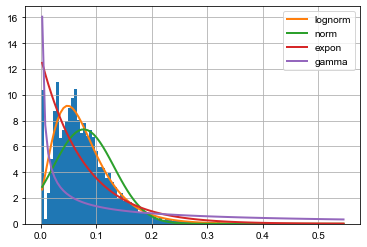

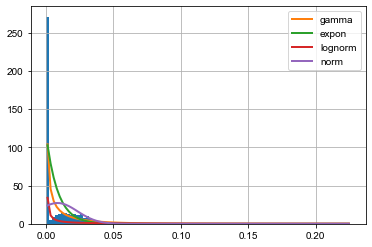

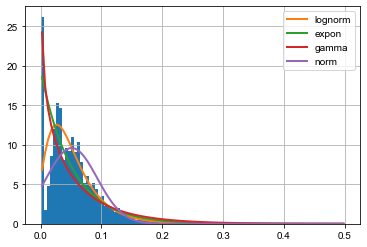

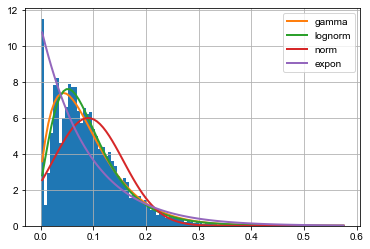

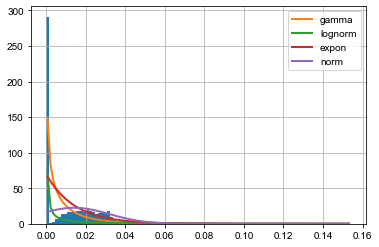

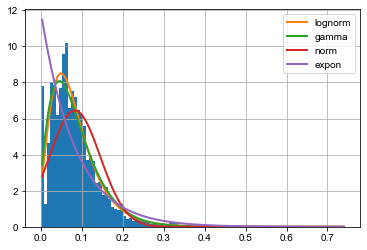

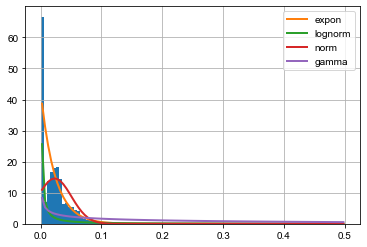

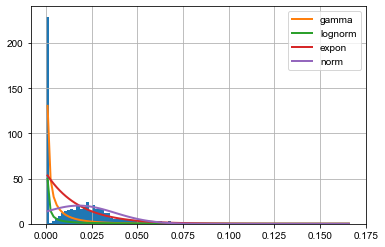

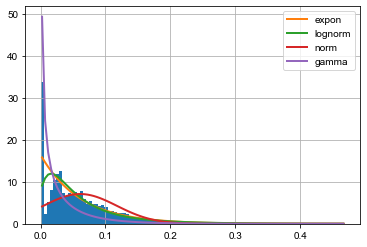

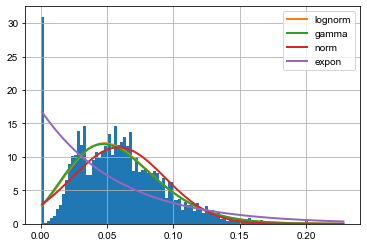

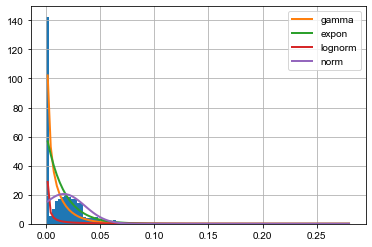

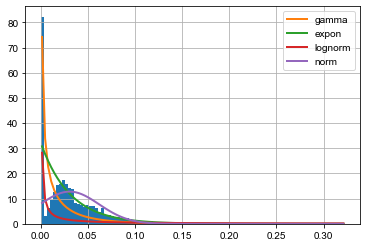

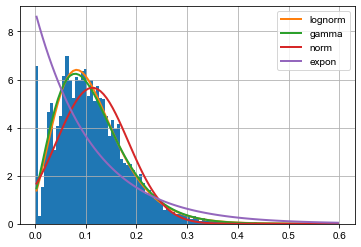

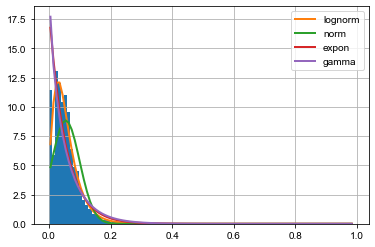

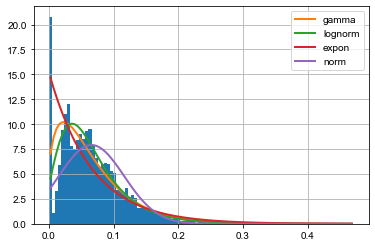

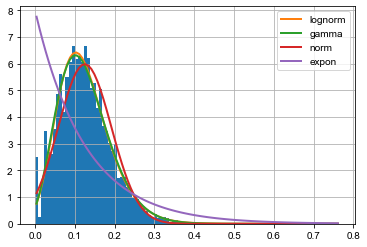

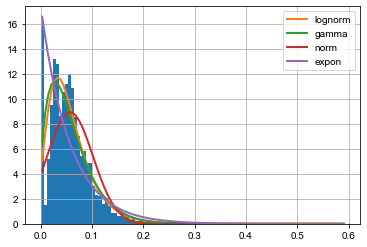

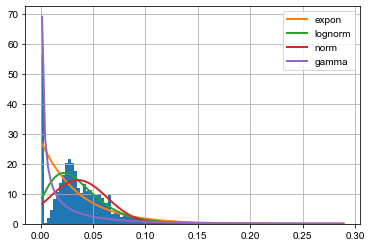

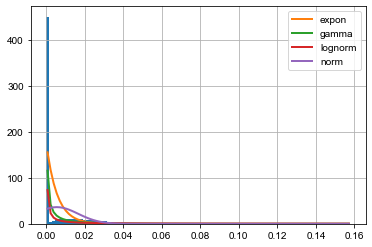

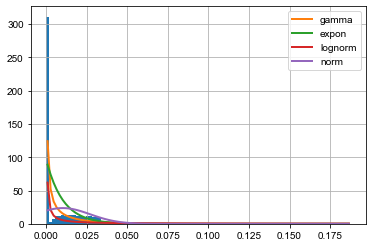

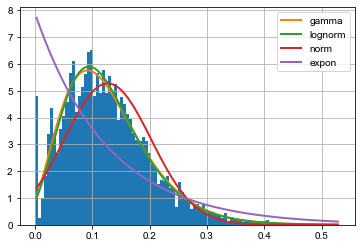

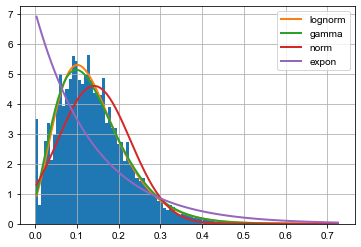

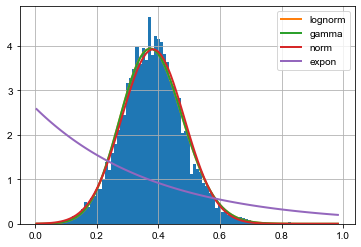

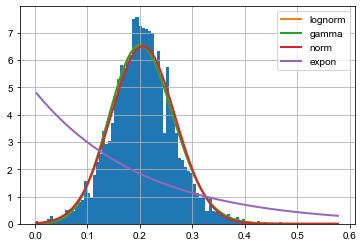

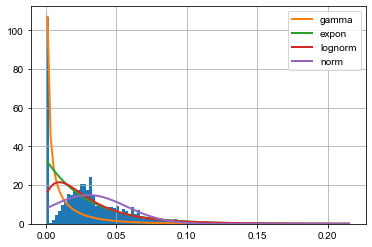

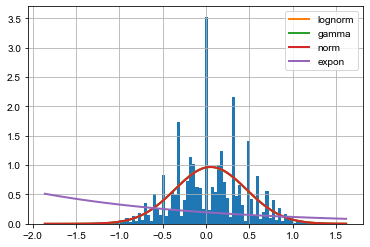

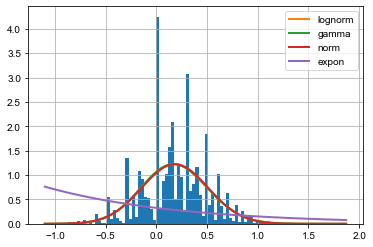

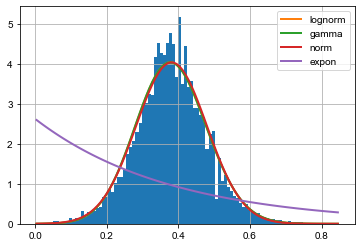

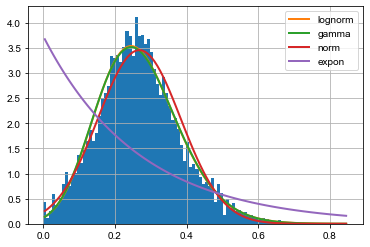

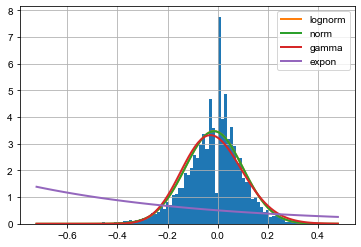

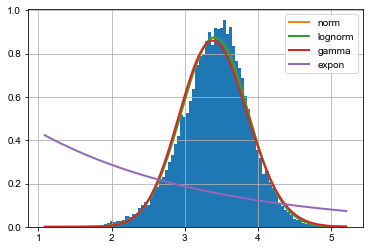

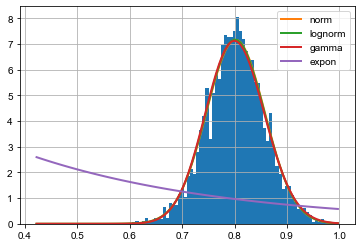

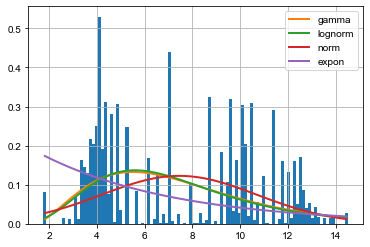

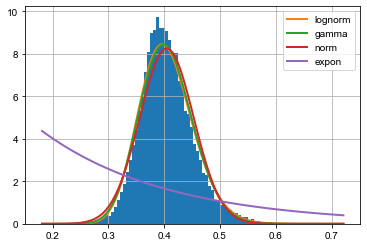

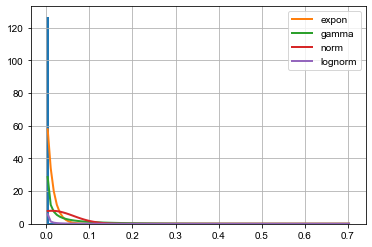

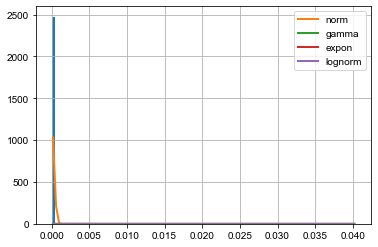

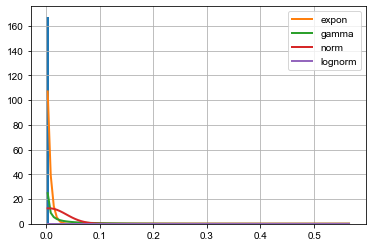

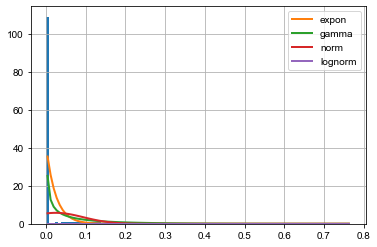

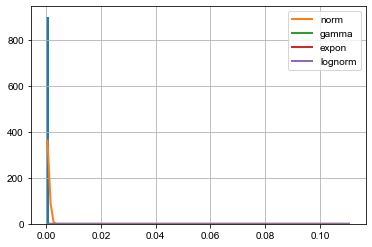

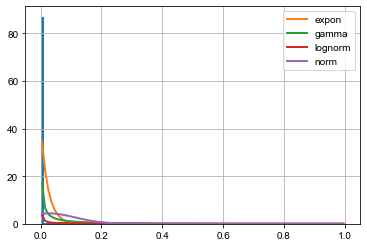

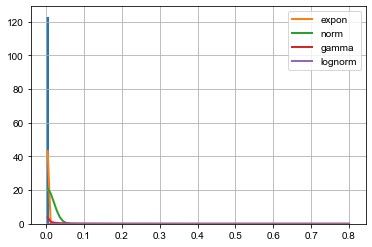

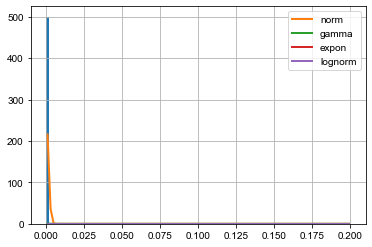

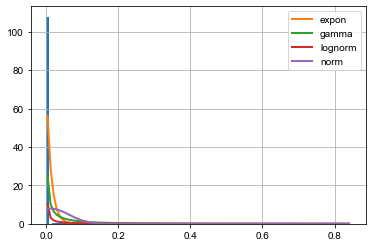

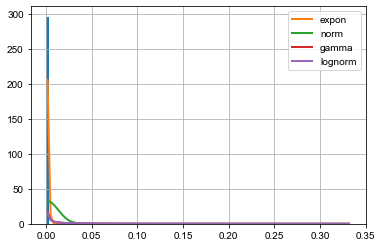

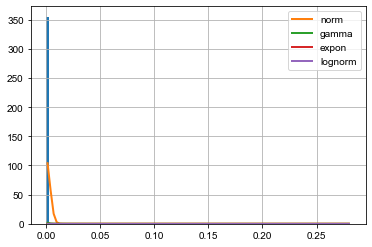

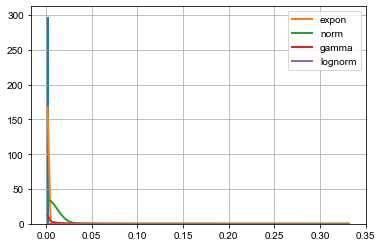

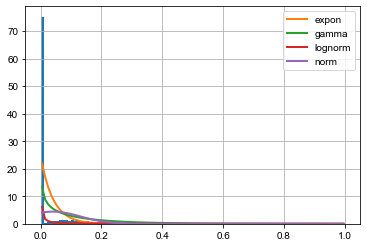

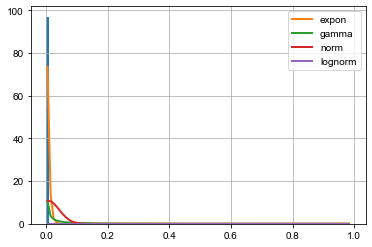

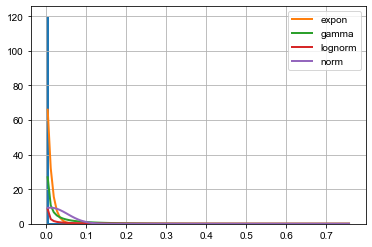

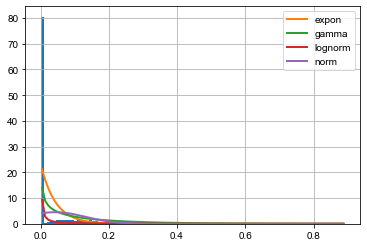

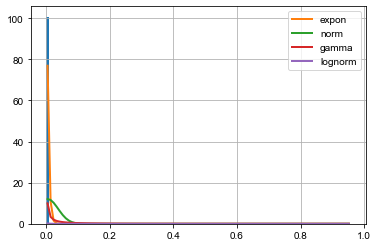

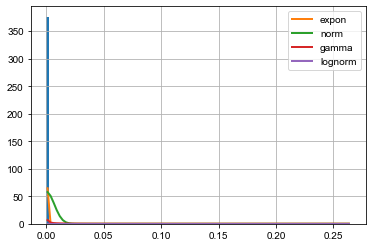

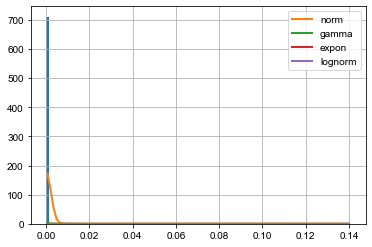

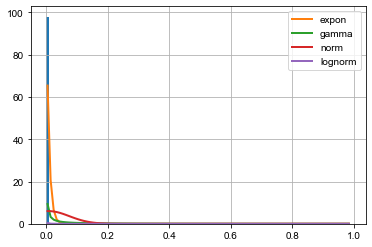

In [69]:
#myfeatcomp=['Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','Y Patch','RG Frac','Patch K+R','Patch D+E','Patch Polar','Patch Aliphatic','Patch Aromatic']
myfeatcomp=['Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','Y Patch','RG Frac']
#fittypes=['gamma','lognorm','expon','norm','chi2']
#fittypes=['gamma','weibull_min','lognorm','norm']
fittypes=['gamma','expon','lognorm','norm']
#fittypes=['cauchy','chi2','expon','exponpow','gamma','lognorm','norm','powerlaw','rayleigh']
#varlist=[fracA, fracC, fracD, fracE, fracF, fracG, fracH, fracI, fracK, fracL, fracM, fracN, fracP, fracQ, fracR, fracS, fracT, fracV, fracW, fracY, fracpos, fracneg, fracpol, fracali, fracaro, fracRtoK, fracEtoD, fracexp, fcr, ncpr, mhydro, dispro, isopoi, ppii]

featfit=[]
bestdistfit=[]
regmean=[]
regvar=[]
fitmean=[]
fitvar=[]
ksstat=[]
ksstatmat=np.zeros((len(myfeatcomp),len(fittypes)))
for i in range(0,len(varlist)):
    currdata=varlist[i]
    #currdata=np.random.gamma(shape=3, scale=1, size=1000) # test gamma distribution
    #myfit = Fitter(currdata,distributions='norm')
    myfit = Fitter(currdata,
               distributions=fittypes)
    plt.figure()
    plt.title(myfeatcomp[i])
    myfit.fit()
    sumdf=myfit.summary()
    #sumdf=sumdf.sort_values(by='sumsquare_error')
    print(sumdf)
    print(sumdf.columns)
    print(list(myfit.get_best(method = 'sumsquare_error').keys())[0])
    print(sumdf['ks_pvalue'].tolist()[0])
    currbestdistfit=list(myfit.get_best(method = 'sumsquare_error').keys())[0]
    bestdistfit.append(currbestdistfit)
    featfit.append(myfeatcomp[i])
    ksstat.append(sumdf['sumsquare_error'].tolist()[0])
    
    currlist=sumdf.index.tolist()
    for f in range(0,len(fittypes)):
        if fittypes[f] in currlist:
            idx=currlist.index(fittypes[f])
            ksstatmat[i,f]=sumdf['ks_statistic'].tolist()[idx]
        else:
            ksstatmat[i,f]=np.nan
    
    print('REGULAR')
    print(np.mean(currdata))
    print(np.var(currdata))
    regmean.append(np.mean(currdata))
    regvar.append(np.var(currdata))

    if currbestdistfit=='gamma':
        print('GAMMA')
        fit_alpha, fit_loc, fit_beta = stats.gamma.fit(currdata)
        gammamean = stats.gamma.mean(fit_alpha,fit_loc,fit_beta)
        gammavar = stats.gamma.var(fit_alpha,fit_loc,fit_beta)
        print(gammamean)
        print(gammavar)
        fitmean.append(gammamean)
        fitvar.append(gammavar)

    elif currbestdistfit=='lognorm':
        print('LOGNORM')
        shape, loc, scale = stats.lognorm.fit(currdata)
        lognormmean = stats.lognorm.mean(shape, loc, scale)
        lognormvar = stats.lognorm.var(shape, loc, scale)
        print(lognormmean)
        print(lognormvar)
        fitmean.append(lognormmean)
        fitvar.append(lognormvar)

    elif currbestdistfit=='expon':        
        print('EXPONENTIAL')
        loc, scale = stats.expon.fit(currdata)
        expmean = stats.expon.mean(loc, scale)
        expvar = stats.expon.var(loc, scale)
        print(expmean)
        print(expvar)  
        fitmean.append(expmean)
        fitvar.append(expvar)
        
    elif currbestdistfit=='norm':
        print('NORM')
        normmean, normstd = stats.norm.fit(currdata)
        print(normmean)
        print(normstd**2)
        fitmean.append(normmean)
        fitvar.append(normstd**2)
        

## 1.6 - Plot KS statistic

hi
                 Feature     gamma     expon   lognorm      norm
0                 Frac A  0.435510  0.154497  0.039664  0.083829
1                 Frac C  0.609597  0.609597  0.609597  0.329436
2                 Frac D  0.153002  0.130284  0.090673  0.108522
3                 Frac E  0.050380  0.130572  0.043147  0.087917
4                 Frac F  0.447935  0.447935  0.447902  0.238131
5                 Frac G  0.044196  0.152046  0.040755  0.100105
6                 Frac H  0.707108  0.328505  0.450675  0.197835
7                 Frac I  0.456999  0.381671  0.482104  0.197703
8                 Frac K  0.396631  0.156398  0.111495  0.139386
9                 Frac L  0.049472  0.196637  0.047857  0.052390
10                Frac M  0.399013  0.399013  0.486752  0.202794
11                Frac N  0.357804  0.264567  0.411005  0.161266
12                Frac P  0.027117  0.184780  0.024146  0.061167
13                Frac Q  0.150441  0.139841  0.075015  0.113647
14                Frac

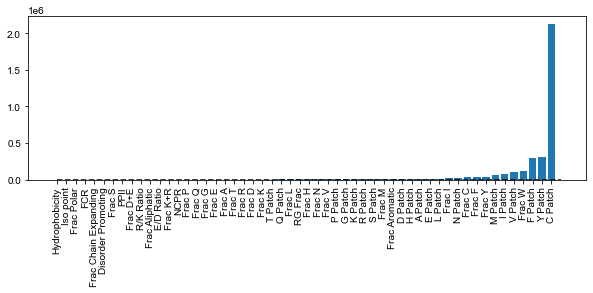

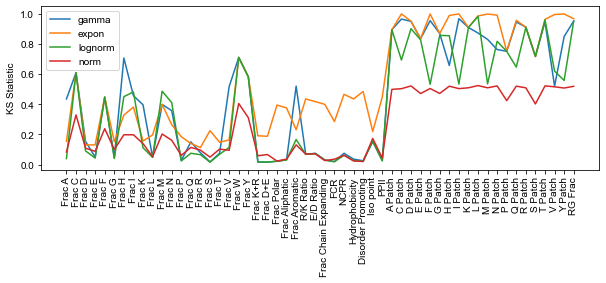

In [70]:
tmpdf=pd.DataFrame()
tmpdf['Feature']=featfit
tmpdf['KS Stat']=ksstat
tmpdf=tmpdf.sort_values(by='KS Stat')

plt.figure(figsize=(10,3))
plt.bar(np.arange(0,len(tmpdf)),tmpdf['KS Stat'].tolist())
plt.xticks(np.arange(0,len(tmpdf)),tmpdf['Feature'].tolist(),rotation=90)
plt.plot([0,54],[0.05,0.05],'--k')
print('hi')

plt.figure(figsize=(10,3))
plt.plot(ksstatmat)
plt.xticks(np.arange(0,len(featfit)),featfit,rotation=90)
plt.legend(fittypes)
plt.ylabel("KS Statistic")
#plt.savefig('KS_statistic_by_feature_4_distributions.pdf', transparent=True, bbox_inches = "tight")

tdf1=pd.DataFrame(myfeatcomp,columns=['Feature'])
tdf2=pd.DataFrame(ksstatmat,columns=fittypes)
tdf=pd.concat([tdf1,tdf2],axis=1)

print(tdf)

#tdf.to_excel('KS_statistic_by_feature_4_distributions.xlsx')

# Part 2: Analyze IDRs

## 2.1 - Histogram of Sequence Lengths

19384
0.7909254121103313
4529
0.18479680104455687
595
0.0242777868451118


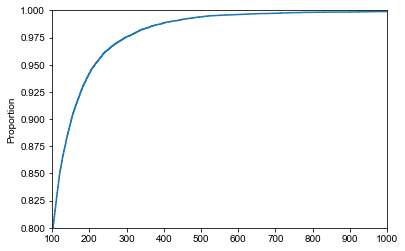

In [6]:
#plt.hist(seqlens,bins=20,cumulative=True,density=False)

#plt.plot(np.sort(seqlens[:-200]),'o')

#plt.hist(np.sort(seqlens[:-200]),bins=50)
#plt.xlim([0, 1000])

sbn.ecdfplot(seqlens)
plt.xlim([100, 1000])
plt.ylim([0.8,1])

tmp=[i for i,v in enumerate(seqlens) if 0 <= v <= 99]
print(len(tmp))
print(len(tmp)/24508)

tmp=[i for i,v in enumerate(seqlens) if 100 <= v <= 300]
print(len(tmp))
print(len(tmp)/24508)

tmp=[i for i,v in enumerate(seqlens) if v > 300]
print(len(tmp))
print(len(tmp)/24508)


## 2.2 - Extract IDRs of length between 100 and 300

In [7]:
# Get all IDRs of length between 100 - 300
minlength=100
maxlength=300
allidx_sub=[i for i,v in enumerate(seqlens) if minlength <= v <= maxlength]


genenames=[]
genenamesIDRnum=[]
accs_sub=[]
currseqs=[]
curraccwnum=[]
for i in allidx_sub:
    curracc=fullaccs[i]
    
    # Get gene names with IDR number
    genenamesIDRnum.append(mygenes[i])
    #print(genenamesIDRnum)
    #print(myseqs[i])
    #print(seqlens[i])
    
    # Get gene names
    tmp=mygenes[i].split(' ')
    genenames.append(tmp[0])
    #print(genenames)
    
    # Get accessions
    accs_sub.append(fullaccs[i])
    
    # Get sequences
    currseqs.append(myseqs[i])
    
    # Get accessions with IDR numbers
    curraccwnum.append(fullaccswnums[i])
    
    #with open('IDR_'+str(minlength)+'_'+str(maxlength)+'.fasta', 'a') as f:
    #    f.write('>'+mygenes[i]+'\n')
    #    f.write(myseqs[i]+'\n')

    
print(genenames)
print(genenamesIDRnum)
print(len(genenamesIDRnum))




['PPP4R3B', 'MEPE', 'MEPE', 'TCEAL5', 'FLG', 'TNRC6B', 'TNRC6B', 'TNRC6B', 'STON2', 'TAF1C', 'ARHGAP39', 'ARHGAP39', 'CDK16', 'E2F3', 'SUGP2', 'PBX2', 'FAT3', 'ARHGEF26', 'SPECC1', 'SPECC1', 'FAM221B', 'ANKRD20A3P', 'KCNH4', 'HUWE1', 'HUWE1', 'Q6ZTI0', 'TRIM44', 'ARIH2OS', 'COL20A1', 'Q8N6K4', 'JARID2', 'JARID2', 'JARID2', 'KAT2A', 'ATXN3L', 'EDA', 'PHIP', 'PPFIBP1', 'HDAC1', 'DHX8', 'SNRK', 'ADAMTS12', 'BBC3', 'MNDA', 'TRPS1', 'ETV6', 'PACS2', 'H1-10', 'FAM102A', 'ZXDC', 'MARK3', 'MUC19', 'MUC19', 'MUC19', 'MUC19', 'MLXIP', 'TONSL', 'TONSL', 'POM121', 'POM121', 'PHACTR2', 'PHACTR2', 'CDT1', 'NPHP4', 'GPATCH8', 'DENND1A', 'DENND1A', 'DENND1A', 'FRY', 'IGF2-AS', 'KNDC1', 'PPP1R13L', 'CENPT', 'NRG1', 'NRG1', 'NFIB', 'TNRC18', 'TNRC18', 'TNRC18', 'TNRC18', 'MYBBP1A', 'WDR91', 'COL26A1', 'MAGEB1', 'ZSCAN21', 'TAF1', 'FAM83H', 'ZNF512B', 'CENPC', 'CENPC', 'NACAD', 'MCF2L', 'GARRE1', 'ZBTB5', 'SYNM', 'ZBTB38', 'MUC5B', 'MUC5B', 'MUC5B', 'LOC729421', 'PTPN18', 'RGS3', 'NUP153', 'FXR2', 'FXR1'

## 2.3 - Test K-means clustering

[[ 2.65558243  3.          2.06370213 ... -0.05093994 -0.02154149
  -0.12989614]
 [-0.37402203 -0.3406979  -1.30681712 ... -0.05093994 -0.02154149
  -0.12989614]
 [-0.90138878  0.          0.5517045  ... -0.05093994 -0.02154149
  -0.12989614]
 ...
 [ 1.49196539 -0.0137946   1.07698451 ... -0.05093994 -0.02154149
  -0.12989614]
 [ 1.9883143   0.          0.98092741 ... -0.05093994 -0.02154149
  -0.12989614]
 [ 0.99828791 -0.54342043  0.         ... -0.05093994 -0.02154149
  -0.12989614]]
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


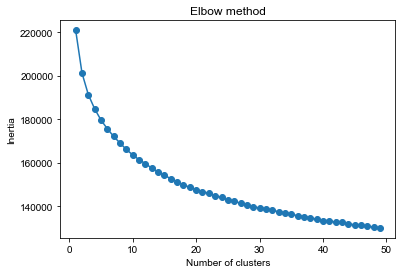

90


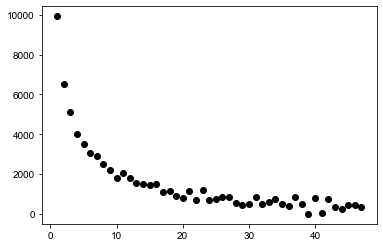

In [11]:
from sklearn.cluster import KMeans

cutoff=3

zvecaasub=zvecaa[allidx_sub,:]
for z in range(0,len(zvecaasub)):
    pos=[i for i, ltr in enumerate(zvecaasub[z,:]) if ltr > cutoff]
    zvecaasub[z,pos]=cutoff
    pos=[i for i, ltr in enumerate(zvecaasub[z,:]) if ltr < -cutoff]
    zvecaasub[z,pos]=-cutoff

data = zvecaasub
print(data)
inertias = []

maxnum=50

for i in range(1,maxnum):
    print(i)
    kmeans = KMeans(init="random",n_clusters=i, n_init=10, random_state=1)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,maxnum), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

print(len(data[0]))

plt.figure()
for i in range(1,maxnum-2):
    plt.plot(i,inertias[i]-inertias[i+1],'ok')
    
#plt.ylim([0])

484.5227181680778
[9934.921823630692, 6542.555907302856, 5139.443679282616, 4010.2347990219714, 3497.3008362242836, 3073.9847355625243, 2928.39175254968, 2516.3284080510784, 2189.405107116938, 1810.0911753439286, 2034.2618915237545, 1809.2021943925356, 1538.3121059300902, 1497.740133310319, 1432.9996298508777, 1474.3938912921294, 1072.1436141759914, 1121.8495265430538, 886.8264843484794, 806.2095577549189, 1124.8981963485421, 706.9102279191429, 1181.456639632379, 705.2984489916416, 766.1246099825366, 821.322519829584, 845.2654768125212, 555.3680750994827, 462.13178058352787, 472.32258692901814, 846.3468196659232, 481.60534189568716, 580.5474943395238, 724.3328341229062, 476.3343354804965, 396.305394412193, 853.9331828452705, 508.40760089922696, -5.718113406008342, 805.3036079242884, 30.296548301295843, 757.9668185043265, 330.17628920660354, 238.04613444925053, 447.5855400242872, 447.25879063845787, 318.1575895535934]


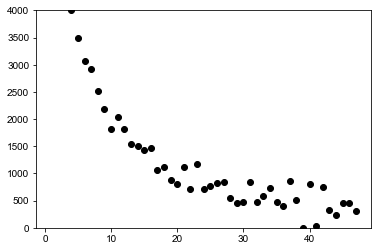

In [12]:
plt.figure()
tmplist=[]
for i in range(1,maxnum-2):
    plt.plot(i,inertias[i]-inertias[i+1],'ok')
    tmplist.append(inertias[i]-inertias[i+1])
    
plt.ylim([0,4000])
currmean=np.mean(tmplist[maxnum-20:])
print(currmean)
print(tmplist)

49


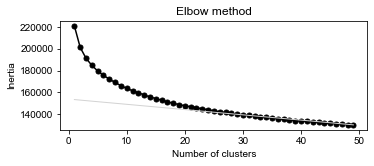

In [13]:
plt.figure(figsize=(5.5,2))
plt.plot(range(1,maxnum), inertias, marker='o',color='black',markersize=5)
plt.plot([1,maxnum-1],[inertias[maxnum-2]+(maxnum-2)*currmean,inertias[maxnum-2]],'-',color='#d3d3d3',linewidth=1)
#plt.plot([1,maxnum-1],[inertias[maxnum-2]+(maxnum-2)*494,inertias[maxnum-2]],'-r')
#plt.plot([0,49],[inertias[48]+48*555,inertias[48]],'-r')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

#plt.ylim([130000,160000])
print(len(inertias))
#plt.savefig('Elbow_Method_IDR_100_300_Kmeans_1_to_49_clusters.pdf', transparent=False, bbox_inches = "tight")


In [11]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cutoff=3

zvecaasub=zvecaa[allidx_sub,:]
for z in range(0,len(zvecaasub)):
    pos=[i for i, ltr in enumerate(zvecaasub[z,:]) if ltr > cutoff]
    zvecaasub[z,pos]=cutoff
    pos=[i for i, ltr in enumerate(zvecaasub[z,:]) if ltr < -cutoff]
    zvecaasub[z,pos]=-cutoff

data = zvecaasub
print(data)
inertias = []

maxnum=100
rs=[1, 11, 21, 31, 41]

sscore=[[] for _ in range(len(rs))]
knum=[]
for r in range(0,len(rs)):
    for i in range(10,maxnum):
        #print(i)
        X = data
        kmeans = KMeans(init="random",n_clusters=i, n_init=10,random_state=rs[r])
        print(str(i)+': '+str(silhouette_score(X, kmeans.fit_predict(X))))
        sscore[r].append(silhouette_score(X, kmeans.fit_predict(X)))
        if r==0:
            knum.append(i)
    

[[ 2.65558243  3.          2.06370213 ... -0.05093994 -0.02154149
  -0.12989614]
 [-0.37402203 -0.3406979  -1.30681712 ... -0.05093994 -0.02154149
  -0.12989614]
 [-0.90138878  0.          0.5517045  ... -0.05093994 -0.02154149
  -0.12989614]
 ...
 [ 1.49196539 -0.0137946   1.07698451 ... -0.05093994 -0.02154149
  -0.12989614]
 [ 1.9883143   0.          0.98092741 ... -0.05093994 -0.02154149
  -0.12989614]
 [ 0.99828791 -0.54342043  0.         ... -0.05093994 -0.02154149
  -0.12989614]]
10: 0.04552049622107222
11: 0.0476005850009236
12: 0.04549513700343423
13: 0.04887045182542497
14: 0.04758848610870863
15: 0.04855732247517834
16: 0.041516174050828046
17: 0.04723487032523831
18: 0.04241449799086963
19: 0.04300459845176555
20: 0.04332604608166629
21: 0.04660764099055631
22: 0.04325141040304041
23: 0.04002771700231257
24: 0.04172376612258993
25: 0.040231089397750844
26: 0.04187303084602549
27: 0.04062814289383316
28: 0.04366994374523805
29: 0.04283890932406849
30: 0.03870278076801743
31:

58: 0.042074332068292766
59: 0.040877993827451886
60: 0.04098075941158538
61: 0.03901937701343544
62: 0.040591275818911046
63: 0.04043280693553289
64: 0.03762269594511081
65: 0.03964373430129464
66: 0.03658671758502799
67: 0.03761667519747132
68: 0.03820838921055338
69: 0.04134970271008963
70: 0.0407636898743408
71: 0.0384406674952391
72: 0.039787794071709626
73: 0.03980903584528267
74: 0.036703567850902924
75: 0.03881065677758647
76: 0.039244415583000763
77: 0.037166520278578925
78: 0.03669465206583342
79: 0.0377750969033846
80: 0.03898148717147336
81: 0.03725997744826078
82: 0.039519508705029426
83: 0.039347842367917045
84: 0.03936313081723802
85: 0.04001635974069585
86: 0.039997523151715446
87: 0.03921781884587419
88: 0.0384082768613171
89: 0.0387612352336492
90: 0.03970064504218372
91: 0.040505906722241886
92: 0.04052383213216672
93: 0.0405898696756489
94: 0.040048059403828114
95: 0.038086629312906156
96: 0.03979991281720433
97: 0.03890748483457594
98: 0.03890323562685196
99: 0.038

90
0.041854633954147
0.04114871218988428
0.0423294064598778
0.042336675265765414
0.04117405987068432
[0.04366994374523805, 0.04283890932406849, 0.03870278076801743, 0.03990277885086831, 0.03961096880291096]


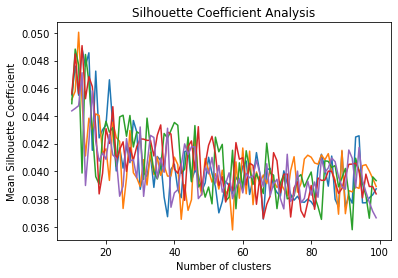

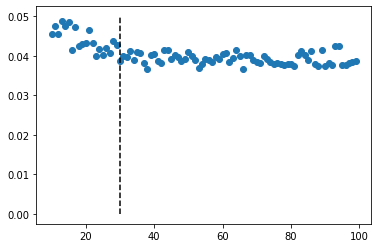

In [12]:
print(len(sscore[0]))
for i in range(0,len(rs)):
    plt.plot(knum[0:90],sscore[i],'-')
    print(np.mean(sscore[i][0:40]))
#plt.plot([10,maxnum],[0.35, 0.35],'--k')
#plt.plot([30,30],[0,0.4],'--k')
#plt.plot([50,50],[0,0.4],'--k')
plt.title('Silhouette Coefficient Analysis')
plt.xlabel('Number of clusters')
plt.ylabel('Mean Silhouette Coefficient')

print(sscore[0][18:23])
plt.figure()
plt.plot(np.arange(10,100,1),sscore[0],'o')
plt.plot([30,30],[0,0.05],'--k')
#plt.plot([50,50],[0,0.4],'--k')

## 2.4 - Get K-means clusters

In [14]:
from sklearn.cluster import KMeans

cutoff=3

zvecaasub=zvecaa[allidx_sub,:]
for z in range(0,len(zvecaasub)):
    pos=[i for i, ltr in enumerate(zvecaasub[z,:]) if ltr > cutoff]
    zvecaasub[z,pos]=cutoff
    pos=[i for i, ltr in enumerate(zvecaasub[z,:]) if ltr < -cutoff]
    zvecaasub[z,pos]=-cutoff

data = zvecaasub

#instantiate the k-means class, using optimal number of clusters
numkclusts=30
kmeans = KMeans(init="random", n_clusters=numkclusts, n_init=10, random_state=1)

#fit k-means algorithm to data
kmeans.fit(data)

#view cluster assignments for each observation
clusters=kmeans.labels_

print(clusters)
numclust=max(clusters)
print(numclust)

#[18  4  4 ...  3  5 11]

[18  4  4 ...  3  5 11]
29


## 2.5 - Get centroids of clusters - i.e., IDR most similar to all others in cluster

In [16]:
import scipy

clustcent=[]

for c in range(0,numclust+1):
    midx = [i for i, x in enumerate(clusters) if x == c]
    # Find which protein has the lowest distance in terms of zscores from all other proteins in the cluster
    tmpmat=[]
    currgenelist=[]
    curracclist=[]
    currseqlist=[]
    for i in midx:
        tmpmat.append(zvecaa[allidx_sub[i],:])
        currgenelist.append(genenamesIDRnum[i])
        curracclist.append(accs_sub[i])
        currseqlist.append(currseqs[i])
        #print(genes_rrm[i])
    
    distvec=scipy.spatial.distance.pdist(tmpmat)
    distmat=scipy.spatial.distance.squareform(distvec)
    
    mdist=[]
    for l in distmat:
        mdist.append(np.mean(l))
        
        
    min_value = min(mdist)
    min_index=mdist.index(min_value)
    #print(mdist)
    #print(min_index)
    print('Cluster_'+str(c))
    print('>'+currgenelist[min_index])
    print(currseqlist[min_index])
    clustcent.append(currgenelist[min_index])

Cluster_0
>ZSWIM8 IDR2
LDKLLDRESQTHKPQTLSSFYSSSRPTTASQRSPSKHGGPSAPGALQPLTSGSAGPAQPGSVAGAGPGPTEGFTEKNVPESSPHSPCEGLPSEAALTPRPEGKVPSRLALGSRGGYNGRGWGSPGRPKKKHTGMASIDSSAPETTSDSSPTLSRRPLRGGWAPTSWGRGQDSDSISSSSSDSLGSSSSSGSRRASASGGARAKTVEVGRYKGRRPESHAPHVPNQP
Cluster_1
>LPP IDR1
MSHPSWLPPKSTGEPLGHVPARMETTHSFGNPSISVSTQQPPKKFAPVVAPKPKYNPYKQPGGEGDFLPPPPPPLDDSSALPSISGNFPPPPPLDEEAFKVQGNPGGKTLEERRSSLDAEIDSLTSILADLECSSPYKPRPPQSSTGSTASPPVSTPVTGHKRMVIPNQPPLTATKKSTLKPQPAPQAGPIPVAPIGTLKPQPQPVPASYTTASTSSRPTFN
Cluster_2
>ZFHX2 IDR15
LLGKVDDGTGREAPKREAPAFPYPTATLASGPQPFLPPGKEATTPTPEPPLPLLPPPPPSEEEGPEEPPKASPESEACSLSAGDLSDSSASSLAEPESPGAGGTSGGPGGGTGVPDGMGQRRYRTQ
Cluster_3
>SPHKAP IDR8
ETDQREACAGEPEPFLSKSSLLEEAEGHSNDKNIPDVVRGGDTAVSACQIHSDSLDTRDVPEAEASTEARAPDEAPNPPSSSEESTGSWTQLANEEDNPDDTSSFLQLSERSMSNGNSSATSSLGIMDL
Cluster_4
>ZZZ3 IDR2
QLTTEPATGPFSETQSSLRDSEEEVDVVGDSSASKEQCKENTNNELDTSLESMPASGEPEPSPVLDCVSAQMMSLSEPQEHRYTLRTSPRRAAPTRGSPTKNSSPYRENGQFEENNLSPNETNATVSDNVSQSPTNPGEISQNEKGICCDSQNNGSEGVSKPPSEARLNIGHLPSAKESASQH

## 2.6 - Get cluster lists

In [17]:
genelistclust=[]
listclust=[]
acclistbyclust=[]
for c in range(0,numclust+1):
    print('Cluster_'+str(c))
    pos=[i for i, ltr in enumerate(clusters) if ltr == c]
    print(pos)

    acclist=[]
    seqlist=[]
    genelist=[]
    for p in pos: 
        acclist.append(curraccwnum[p])
        seqlist.append(currseqs[p])
        if genenamesIDRnum[p] in clustcent:
            genelist.append('*'+genenamesIDRnum[p])
        else:
            genelist.append(genenamesIDRnum[p])
        genelistclust.append(genenamesIDRnum[p])
        listclust.append(c)
        #print(p)
        print(curraccwnum[p])
        print(genenamesIDRnum[p])
        print(currseqs[p])
    
    currdf=pd.DataFrame()
    currdf['Uniprot']=acclist
    currdf['Genes']=genelist
    currdf['Sequences']=seqlist
    
    acclistbyclust.append(acclist)
    print(acclist)
    print(len(acclist))

    
    #if c==0:
    #    with pd.ExcelWriter('2023_09/IDR_'+str(minlength)+'_'+str(maxlength)+'_kmeans_'+str(numkclusts)+'_clusters_v2.xlsx') as writer:  
    #        currdf.to_excel(writer, sheet_name='cluster_'+str(c))
    #else:
    #    with pd.ExcelWriter('2023_09/IDR_'+str(minlength)+'_'+str(maxlength)+'_kmeans_'+str(numkclusts)+'_clusters_v2.xlsx',engine="openpyxl",mode='a') as writer:  
    #        currdf.to_excel(writer, sheet_name='cluster_'+str(c))

Cluster_0
[12, 13, 81, 104, 132, 136, 227, 239, 267, 395, 574, 613, 638, 720, 737, 788, 806, 863, 976, 980, 1066, 1068, 1202, 1218, 1222, 1285, 1314, 1334, 1358, 1608, 1642, 1677, 1717, 1733, 1774, 1799, 1813, 1838, 1890, 1927, 1969, 2010, 2066, 2117, 2118, 2140, 2147, 2249, 2391, 2444, 2466, 2549, 2566, 2590, 2594, 2675, 2784, 2805, 2846, 2878, 2893, 2949, 2957, 2997, 3023, 3145, 3153, 3172, 3207, 3233, 3243, 3245, 3249, 3258, 3341, 3390, 3396, 3409, 3471, 3500, 3628, 3631, 3633, 3665, 3667, 3686, 3704, 3744, 3758, 3804, 3899, 3904, 3943, 3944, 3953, 4008, 4012, 4056, 4149, 4173, 4185, 4230, 4268, 4281, 4291, 4309, 4363, 4479, 4487, 4507]
Q00536_1
CDK16 IDR1
MDRMKKIKRQLSMTLRGGRGIDKTNGAPEQIGLDESGGGGGSDPGEAPTRAAPGELRSARGPLSSAPEIVHEDLKMGSDGESDQASATSSDEVQSPVRVRMRNHPPRKISTEDINK
O00716_1
E2F3 IDR1
TTSCSSSLQSGAVAAGPLLPSAPGAEQTAGSLLYTTPHGPSSRAGLLQQPPALGRGGSGGGGGPPAKRRLELGESGHQYLSDGLKTPKGKGRAALRSPDSPKTPKSPSEKTRYD
A4D1P6_1
WDR91 IDR1
QRNASLSQSPRVGFLSSLLPQSKKSPSRLSPAQGPPQPQSSAKKESFGGQGTKGKDPTSGA

DNMBP IDR2
ENTLGVEEQRHETSDHEAEEPDCIISEAPTSPLGHLTSEYDTDRNSYQDEDTAGGPPRSPGVEWEMPLATDSPTSDPTEVVNGISSQPQVPFHPNLQKSQYYSTVGGSHPHSEQYPDLLPL
Q86WP2_4
GPBP1 IDR4
FKSTAKNFSPSTNSVKECNRSNSSSPVDKLNQQPRLTKLTRMRTDKKSEFLKALKRDRVEEEHEDESRAGSEKDDDSFNLHNSNSTHQERDINRNFDENEIPQENGNASVISQ
Q5T1R4_3
HIVEP3 IDR3
SGMGGEMYPHGLEMERIPGEEFEEPTEGESTDSEEETSATSGHPAELSPRPKQPLLSSGLYSSGSHSSSHERCSLSQSSTAQSLEDPPPFVEPSSEHPLSHKPEDTHTIKQKLALRL
Q9ULJ8_3
PPP1R9A IDR3
GHLKDSNSWPPSNKRGVDTEDAHKSNATPVPEVASKSTSLASIPGEEIQQSKEPEDSTSNQQTPDSIDKDGPEEPCAESKAMPKSEIPSPQSQLLEDAEANLVGREAAKQQRKELAGGDFTSPDASASSCGKEVPEDSNNFDGSHVY
Q86VR2_3
RETREG3 IDR3
RELAITDSEHSDAEVSCTDNGTFNLSRGQTPLTEGSEDLDGHSDPEESFARDLPDFPSINMDPAGLDDEDDTSIGMPSLMYRSPPGAEEPQAPPASRDEAAL
Q9HCC9_1
ZFYVE28 IDR1
QLSRMVHRAGDEMSSLLSPPIACQSPAHRPGAEGSPGGEASPGRPRLRSGSDEEERVFFMDDVEGTAEALARPESPAGPFGWAGSTWADPQEKGQGGPGGAAGISLPASEKEEDLSNNNLEAEGTDGASLAGTSS
Q96BU1_1
S100PBP IDR1
MMCSRVPSEQSSGTSLLPKDGAPFSWDSLDEDGLDDSLLELSEGEEDDGDVNYTEEEIDALLKEDDPSYEQSSGEDDGGHVEKGERGSQILLDTPREKNSSYSLGPVAETPDLFKLPQL

SHHPDYTALSSGDLGGQAGVDFDPSTPPKLMPFSNQLEMGSEKGAVRPTAFKPVLPRSGAILHSSPESASHQLHPAPPDKPKEQELKPGLCSGALSDSGRNSMSSLPTHSTSSSYQLDPLVTPVGPTSRFGGSA
Q6IQ55_5
TTBK2 IDR5
SDLFSRLAQILQNGSQKPRSTTQCKSPGSPHNPKTPPKSPVVPRRSPSASPRSSSLPRTSSSSPSRAGRPHHDQRSSSPHLGRSKSPPSHSGSSSSRRSCQQEHCKPSKNGLKGSGSLHHHSASTKTPQGKSKPASKLSR
Q9UPA5_4
BSN IDR4
SIVRMRQASSRDLAFAEDKKKEKQFLNAESAYMDPMKQNGGPLTPGTSPTQLAAPVSFSTPTSSDSSGGRVIPDVRVTQHFAKETQDPLKLHSSPASPSSASKEIGMPFSQGPGTPATTAVAPCPAGLPRGYMTPASPAGSERSPSPSSTAHSYGHSPTTANYGSQTEDLPQAPSGLAAAGRAAREKPLSASDGEGGTPQPSRAYSYFASSSPPLSPSSPSESPTFSPGKMGPRATAEFSTQTPSPAPASDMPRSPGAPTPSPMVAQGTQTPHRPSTPRLVWQESSQEA
Q15750_1
TAB1 IDR1
GEMSQPTPSPAPAAGGRVYPVSVPYSSAQSTSKTSVTLSLVMPSQGQMVNGAHSASTLDEATPTLTNQSPTLTLQSTNTHTQSSSSSSDGGLFRSRPAHSLPPGEDGRV
P23771_2
GATA3 IDR2
GSHHTASPWNLSPFSKTSIHHGSPGPLSVYPPASSSSLSGGHASPHLFTFPPTPPKDVSPDPSLSTPGSAGSARQDEKECLKYQVPLPDSMKLESSHSRGSMTALGGASSSTHHPITTYPPY
Q6ZRS2_1
SRCAP IDR1
MQSSPSPAHPQLPVLQTQMVSDGMTGSNPVSPASSSSPASSGAGGISPQHIAQDSSLDGPPGPPDGATVPLEGFSLSQAADLANKGPKWEKSHAEIAEQAKH
Q

TTN IDR31
RHAQAAYRQPKQRQRIMAEREDEELLRPVTTTQHLSEYKSELDFMSKEEKSRKKSRRQREVTEITEIEEEYEISKHAQRESSSSASRLLRRRRSLSPTYIELMRPVSELIRSRPQPAEEYEDDTERRSPTPERTRPRSPSPVSSERSLSRFER
P52701_2
MSH6 IDR2
LAVCDEPSEPEEEEEMEVGTTYVTDKSEEDNEIESEEEVQPKTQGSRRSSRQIKKRRVISDSESDIGGSDVEFKPDTKEEGSSDEISSGVGDSESEGLNSPVKVARKRKRMVTGNGSLKRKSSRKETPSATKQATSISSETKNTLRAFSAPQNSESQAHVSGGGDDSSRPT
Q2V2M9_4
FHOD3 IDR4
ERVLQQKQKRANHRERNKTRGKMITDSGKFSGSSPAPPSQPQGLSYAEDAAEHENMKAVLKTSSPSVEDATPALGVRTRSRASRGSTSSWTMGTDDSPNVTDDAADE
Q9UHB6_5
LIMA1 IDR5
AASMEAKASSQQEKEDKPAETKKLRIAWPPPTELGSSGSALEEGIKMSKPKWPPEDEISKPEVPEDVDLDLKKLRRSSSLKERSRPFTVAASFQSTSVKSPKTVSPPIRKGWSMSEQSEESVGGRVAERKQVENAKASKKNGNVGKTTWQNKESKGETGKRSKEGHSLEMENENLVENGADSDEDDNSFLKQQSPQEPKSLNWSSFVDN
Q8NBB4_3
ZSCAN1 IDR3
LPEESEWLETTQLQQSLHTRAEAEAPRAPGLLGSRARLPLKPSIWDEPEDLLAGPSSDLRAEGTVISSPKGPSAQRISPRRRNRNTDQSGRHQPSLKHTKGGTQEAVA
Q92922_1
SMARCC1 IDR1
EEDYEVDENRKPVSFRQRISTKNEEPVRSPERRDRKASANARKRKHSPSPPPPTPTESRKKSGKKGQASLYGKRRSQKEEDEQEDLTKDMEDPTPVPNIEEVVLPKNVNLKKDSENTPVKGGTVADLDEQDEETV

MALEEEEDAEAPPSFSGAQLDSSPSGSVEDEDGDGRLRPSPGLQGAGGAACLGKVSSSGKRAREVHGGQEQALDSPRGMHRDGNTLPSPSSWDLQPELAAPQGTPGPLGVERRGSGKVINQVSLHQDGHLGGAGPP
O14654_2
IRS4 IDR2
ECKEAKEVKDAEIPEGAARGPHRARAFDEDEDDPYVPMRPGVATPLVSSSDYMPMAPQNVSASKKRHSRSPFEDSRGYMMMFPRVSPPPAPSPPKAPDTNKEDDSKDNDSESDYMFMAPGAGAIPKNPRNPQGGSSSKSWSSYFSLPNPFRSSPLGQNDNSEYVPMLPGKFLGRGLDKEVSYNWDPKDAASKPSGEGSFSKPGDGGSPSKPSDHEPPKNKAKRPNRLSFITKGYKIKPKPQKPTHEQREADSSSDYVNMDFTKRESNTPAPSTQGLPDSW
O75152_1
ZC3H11A IDR1
TVLPTVPESPEEEVKASQLSVQQNKLSVQSNPSPQLRSVMKVESSENVPSPTHPPVVINAADDDEDDDDQFSEEGDETKTPTLQPTPEVHNGLRVTSVRKP
Q9Y6N7_2
ROBO1 IDR2
LIQSNLSNNMNNGSGDSGEKHWKPLGQQKQEVAPVQYNIVEQNKLNKDYRANDTVPPTIPYNQSYDQNTGGSYNSSDRGSSTSGSQGHKKGARTPKVPKQGGMNWADLLPPPPAHPPPHSNSEEYNISVDESYDQEMPCPVPPARMYLQQDELEEEEDERGPTPPVRGAASSPAAVSYSHQSTATLTPSPQEELQPMLQDCPEETGHMQHQPDRRRQPVSPPPPPRPISPPHTYGYISGPLVSDMDTDAPEEEEDEADMEVAKMQTR
Q9Y6N7_4
ROBO1 IDR4
VARRQMQDAAGRRHFHASQCPRPTSPVSTDSNMSAAVMQKTRPAKKLKHQPGHLRRETYTDDLPPPPVPPPAIKSPTAQSKTQLEVRPVVVPKLPSMDARTDRSSDRKGSSYKGREVLDGRQVVDMRTNPG

PMS2 IDR1
ADLEKPMVEKQDQSPSLRTGEEKKDVSISRLREAFSLRHTTENKPHSPKTPEPRRSPLGQKRGMLSSSTSGAISDKGVLRPQKEAVSSSHGPSDPTDRAEVEKDSGHGSTSVDSEGFSIPDTGSHCSSEYAASSPGDRGSQEHVDSQEKAPKTDDSFSDVDCHSN
O43283_2
MAP3K13 IDR2
KRHPVRPIIHPNAMEKLMKRKGVPHKSGMQTKRPDLLRSEGIPTTEVAPTASPLSGSPKMSTSSSKSRYRSKPRHRRGNSRGSHSDFAAILKNQPAQENSPHPTYLHQAQSQYPSLHHHNSLQQQYQQPPPAMSQSHHPRLNMHGQ
Q9NZC9_1
SMARCAL1 IDR1
MSLPLTEEQRKKIEENRQKALARRAEKLLAEQHQRTSSGTSIAGNPFQAKQGPSQNFPRESCKPVSHGVIFKQQNLSSSSNADQRPHDSHSFQAKGIWKKPEEMPTACPGHSPRSQMALTGISPPLAQSPPEVPKQQLLSYELGQGHAQASPEIRFTPFANPTHKPLAKPKSSQETPAHSSGQPPRDAKLEAKTAKASPSGQNISYIHSSSESVTPRTEGRLQQKSGSSVQKGVNSQK
Q16254_1
E2F4 IDR1
SSPPVAVPVPPPEDLLQSPSAVSTPPPLPKPALAQSQEASRPNSPQLTPTAVPGSAEVQGMAGPAAEITVSGGPGTDSKDSGELSSLPLGPTTLDTRPLQSSALLDSSSSSSSSSSSSSNSNSSSSSGPNPSTSFEPIKADPTG
Q7Z6B7_3
SRGAP1 IDR3
ALNELRELERQSTAKHAPDVVLDTLEQVKNSPTPATSTESLSPLHNVALRSSEPQIRRSTSSSSDTMSTFKPMVAPRMGVQLKPPALRPKPAVLPKTNPTIGPAPPPQGPTDKSCTM
Q9BY89_3
KIAA1671 IDR3
APLHDPDLDFLEVAKKIRERKEKMLSKPEMGSPRALVGGSSGVTPSNDQSPWEEKAKLDPEPEKAAE

RAASAGQEPLHNEELAGAGRVAQPGPLEPEEPRAGGRPRRRRDLGSRLQAQRRAQRVAWAEADENEEEAVILAQEEEGVEKPAETHLSGKIGAKKLRKLEEKQARKAQREAEEAEREERKRLESQREAEWKKEEERLRLEEEQKEEEERKAREEQAQREHE
Q13111_3
CHAF1A IDR3
LAVRPPQIKSLPATPQGKNMTPESEVLESFPEEDSVLSHSSLSSPSSTSSPEGPPAPPKQHSSTSPFPTSTPLRRITKKFVKGSTEKNKLRLQRDQERLGKQLKLRAEREEKEKLKEEAKRAKEEAKKKKEEEKELKEKERREKREKDEKEKAEKQRLKEERRKERQEALEAKLEEKRKKEEEKRLREEEK
P78332_5
RBM6 IDR5
DPNTQQEVYVPQDPGLPEEEEIKEKKPTSQGKSSSKKEMSKRDGKEKKDRGVTRFQENASEGKAPAEDVFKKPLPPTVKKEESPPPPKVVNPLIGLLGEYGGDSDYEEEEEEEQTPPPQPRTAQPQKREEQTKKENEEDKLTDW
E7EV46_3
ERCC6 IDR3
IKKLQKRALQFQGKVGLPKARRPWESDMRPEAEGDSEGEESEYFPTEEEEEEEDDEVEGAEADLSGDGTDYELKPLPKGGKRQKKVPVQEIDDDFFPSSGEEAEAASVGEGGGGGRKVGRYRDDGDEDYYKQRLSPKMPRTL
Q6IN85_1
PPP4R3A IDR1
ARTLEDEEEMWFNTDEDDMEDGEAVVSPSDKTKNDDDIMDPISKFMERKKLKESEEKEVLLKTNLSGRQSPSFKLSLSSGTKTNLTSQSSTTNLPGSPGSPGSPGSPGSPGSVPKNTSQTAAITTKGGLVGLVDYPDDDEDDDEDEDKEDTLPLSKKAKFDS
Q5H9F3_7
BCORL1 IDR7
KWQPDDVTESLPPKKMKCGKEKDSEEQQLQPQAKAVVRSSHRPKCRKLPSDPQESTKKSPRGASDSGKEHNGVRGKHKHRKPTKPESQSPGK

[47, 80, 111, 112, 144, 199, 223, 266, 285, 286, 294, 315, 371, 412, 438, 447, 452, 464, 471, 473, 498, 501, 507, 539, 563, 584, 599, 665, 671, 882, 896, 907, 990, 1024, 1044, 1046, 1057, 1064, 1123, 1142, 1197, 1203, 1238, 1305, 1322, 1337, 1359, 1372, 1380, 1411, 1552, 1553, 1579, 1601, 1746, 1753, 1820, 1856, 1866, 1887, 1921, 2006, 2017, 2018, 2041, 2072, 2073, 2074, 2116, 2126, 2127, 2209, 2274, 2330, 2358, 2381, 2445, 2446, 2447, 2448, 2449, 2452, 2471, 2486, 2587, 2599, 2663, 2683, 2703, 2717, 2730, 2771, 2826, 2916, 2947, 2979, 3040, 3081, 3085, 3124, 3149, 3158, 3289, 3327, 3365, 3434, 3498, 3534, 3652, 3705, 3727, 3737, 3742, 3756, 3769, 3775, 3782, 3783, 3854, 3883, 3890, 3928, 3933, 4006, 4009, 4034, 4042, 4078, 4079, 4110, 4120, 4170, 4176, 4336, 4379, 4404, 4432, 4441, 4449, 4450, 4451, 4476, 4483, 4525]
Q92522_2
H1-10 IDR2
GTGANGSFKLNRKKLEGGGERRGAPAAATAPAPTAHKAKKAAPGAAGSRRADKKPARGQKPEQRSHKKGAGAKKDKGGKAKKTAAAGGKKVKKAAKPSVPKVPKGRK
Q9BQG0_2
MYBBP1A IDR2
LGVQRPKLEKKDAKEIPSAT

FAM90A1 IDR2
LVPPNFGEKEGKENLKPWKPQVEANPGPLNKDKGEKEERPRPQDPQRKALLHIFSRKPPEKPLPNQKGSTESSDYLRVASGPMPVHTTSKRPRVDPVLSDRSATEMSDRGSVLASLSPLRKASLSSSSSLGPKERQTGAAADIPQTAVRHQGPEPLLVVKPTHSSPAGGCREVPQAASKTHGLLQAVSPQAQDKRPAVTSQPCPPAATHSLGLGSNLSFGPGAKRSAP
Q9UBK2_2
PPARGC1A IDR2
NECSGLSTQNHANHNHRIRTNPAIVKTENSWSNKAKSICQQQKPQRRPCSELLKYLTTNDDPPHTKPTENRNSSRDKCTSKKKSHTQSQSQHLQAKPTTLSLPLTPESPNDPKGSPFENKTIERTLSVELSGTAGLTPPTTPPHKANQDNPFRASPKLKSSCKTVVPPPSKKPRYSESSGTQGNNSTKKGPEQSELYAQLSKSSVLTGGHEERKTKRPSLRLF
Q8IX12_2
CCAR1 IDR2
APQTTFGVQTQPQPQSLLQAQISAASITPLLQTQPQPLLQQPQQKAGLLQPPVRIVSQPQPARRLDPPSRFSGRNDRGDQVPNRKDDRSRERERERRRSRERSPQRKRSRERSPRRERERSPRRVRR
O95873_1
C6orf47 IDR1
MFLRRLGGWLPRPWGRRKPMRPDPPYPEPRRVDSSSENSGSDWDSAPETMEDVGHPKTKDSGALRVSGAASEPSKEEPQVEQLGSKRMDSLKWDQPISSTQESGRLEAGGASPKLRWDHVDSGGTRRPGVSPEGGLSVPGPGAPLEKPGRR
O75449_1
KATNA1 IDR1
STPLKAAQHDLPASEGEVWSMPVPVERRPSPGPRKRQSSQYSDPKSHGNRPSTTVRVHRSSAQNVHNDRGKAVRCREKKEQNKGREEKNKSPAAVTEPETNKFDSTG
Q8IVF1_6
NUTM2A IDR6
WWLPQSPVPASGLLSPEKWGPQGTHQFPSAERRGLNLAP

[27, 42, 69, 77, 99, 100, 135, 234, 248, 280, 310, 352, 381, 386, 407, 455, 457, 519, 528, 544, 601, 605, 609, 642, 643, 644, 654, 661, 687, 692, 696, 702, 714, 723, 725, 739, 802, 809, 825, 827, 840, 841, 869, 872, 885, 937, 950, 958, 971, 993, 1042, 1048, 1078, 1086, 1117, 1186, 1232, 1245, 1253, 1274, 1300, 1326, 1423, 1436, 1462, 1468, 1478, 1520, 1522, 1557, 1564, 1568, 1600, 1622, 1663, 1696, 1704, 1747, 1756, 1772, 1792, 1815, 1840, 1847, 1905, 1950, 2000, 2013, 2016, 2024, 2025, 2026, 2055, 2087, 2101, 2107, 2133, 2145, 2183, 2186, 2189, 2203, 2207, 2253, 2270, 2271, 2282, 2283, 2289, 2296, 2350, 2355, 2443, 2491, 2495, 2523, 2524, 2526, 2585, 2598, 2608, 2616, 2694, 2711, 2714, 2715, 2726, 2729, 2731, 2734, 2751, 2772, 2775, 2790, 2795, 2840, 2864, 2867, 2883, 2884, 2895, 2901, 2907, 2910, 2932, 2937, 2950, 2956, 2976, 2978, 3027, 3059, 3078, 3100, 3131, 3139, 3147, 3148, 3164, 3183, 3206, 3229, 3239, 3242, 3271, 3283, 3299, 3343, 3355, 3383, 3399, 3404, 3419, 3487, 3488, 3504

## Check clusters

In [18]:
for c in range(0,numkclusts):
    tmpdf=pd.read_excel('data/IDR_100_300_kmeans_30_clusters_v2.xlsx',sheet_name='cluster_'+str(c))
    #print(tmpdf)
    
    tmpgenelistclust=(tmpdf['Genes'].tolist())
    tmpacclistbyclust=(tmpdf['Uniprot'].tolist())
    #print(tmpacclistbyclust)
    #print(acclistbyclust[c])
    
    if tmpacclistbyclust==acclistbyclust[c]:
        print('Cluster '+str(c)+' is good')
    else:
        print('Cluster '+str(c)+' is bad')

Cluster 0 is good
Cluster 1 is good
Cluster 2 is good
Cluster 3 is good
Cluster 4 is good
Cluster 5 is good
Cluster 6 is good
Cluster 7 is good
Cluster 8 is good
Cluster 9 is good
Cluster 10 is good
Cluster 11 is good
Cluster 12 is good
Cluster 13 is good
Cluster 14 is good
Cluster 15 is good
Cluster 16 is good
Cluster 17 is good
Cluster 18 is good
Cluster 19 is good
Cluster 20 is good
Cluster 21 is good
Cluster 22 is good
Cluster 23 is good
Cluster 24 is good
Cluster 25 is good
Cluster 26 is good
Cluster 27 is good
Cluster 28 is good
Cluster 29 is good


# Extra - Create NARDINI+ Schematic

## Get features of full IDRome

[0.07741329870246792, 0.008538805724799583, 0.05127727736370751, 0.09008763614629162, 0.014270327223274142, 0.08332631606660568, 0.023213564275380197, 0.01785675831127527, 0.06098073687889461, 0.05867819723550179, 0.016164841817388885, 0.030837123165538154, 0.11307352429649098, 0.05451395702245792, 0.06577801431451794, 0.12502566544640797, 0.05722109753347246, 0.03588171932609476, 0.005580771458323423, 0.010280367691109179, 0.12675875119341254, 0.14136491350999913, 0.38267652923466194, 0.20599481539272863, 0.030131466372706743, 0.05493351039784072, 0.1841411803139005, 0.3811971889999026, 0.26812366470341165, -0.01460616231658658, 3.4110708906101537, 0.8019110880466948, 7.44443247900792, 0.4044778171527079, 0.013228570102474755, 2.8313019279589203e-06, 0.00565433376114803, 0.024103760059206916, 1.1039838114785175e-05, 0.023394616782112673, 0.0014528601714245697, 1.625241407649792e-05, 0.012782162346973061, 0.0011648168919885275, 9.498442431682362e-05, 0.0008614367526042599, 0.0403653516

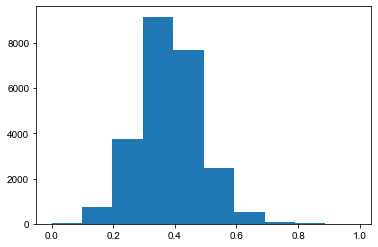

In [31]:

numInt=2 # Number of allowable interruption residues
minBlockLen=4 # Must have at least minBlockLen lysines in the block

aas='ACDEFGHIKLMNPQRSTVY' # For pathces - no W patch in proteome so this is removed
#aas='CEK'

filename=[speciesname]

for fname in filename:
    myfile = open('data/idrs_min_length_30/'+fname, 'r')
    Lines = myfile.readlines()
    fracA=[]
    fracC=[]
    fracD=[]
    fracE=[]
    fracF=[]
    fracG=[]
    fracH=[]
    fracI=[]
    fracK=[]
    fracL=[]
    fracM=[]
    fracN=[]
    fracP=[]
    fracQ=[]
    fracR=[]
    fracS=[]
    fracT=[]
    fracV=[]
    fracW=[]
    fracY=[]
    fracpos=[]
    fracneg=[]
    fracpol=[]
    fracali=[]
    fracaro=[]
    fracRtoK=[]
    fracEtoD=[]
    fracexp=[]
    fcr=[]
    ncpr=[]
    mhydro=[]
    dispro=[]
    isopoi=[]
    ppii=[]
    fracpatch=[[] for _ in range(len(aas))]
    rgpatch=[]
    
    for line in Lines:
        fullline=line.split(" ")
        tmpseq=fullline[3]
        currseq=tmpseq.strip('\n')

        if len(currseq)>=30 and "X" not in currseq and "U" not in currseq and "Z" not in currseq and "J" not in currseq and "B" not in currseq and "O" not in currseq:
            SeqOb = SequenceParameters(currseq)
            slen=SeqOb.get_length()
            aafrac=SeqOb.get_amino_acid_fractions()
            
            fracexp.append(SeqOb.get_fraction_expanding())
            fcr.append(SeqOb.get_FCR())
            ncpr.append(SeqOb.get_NCPR())
            mhydro.append(SeqOb.get_mean_hydropathy())
            dispro.append(SeqOb.get_fraction_disorder_promoting())
            isopoi.append(SeqOb.get_isoelectric_point())
            ppii.append(SeqOb.get_PPII_propensity(mode='hilser'))

            ## AA Fractions
            fracA.append(aafrac['A'])
            fracC.append(aafrac['C'])
            fracD.append(aafrac['D'])
            fracE.append(aafrac['E'])
            fracF.append(aafrac['F'])
            fracG.append(aafrac['G'])
            fracH.append(aafrac['H'])
            fracI.append(aafrac['I'])
            fracK.append(aafrac['K'])
            fracL.append(aafrac['L'])
            fracM.append(aafrac['M'])
            fracN.append(aafrac['N'])
            fracP.append(aafrac['P'])
            fracQ.append(aafrac['Q'])
            fracR.append(aafrac['R'])
            fracS.append(aafrac['S'])
            fracT.append(aafrac['T'])
            fracV.append(aafrac['V'])
            fracW.append(aafrac['W'])
            fracY.append(aafrac['Y'])

            ## AA Physicochemical properties
            fracpos.append(aafrac['K']+aafrac['R'])
            fracneg.append(aafrac['D']+aafrac['E'])
            fracpol.append(aafrac['Q']+aafrac['N']+aafrac['S']+aafrac['T']+aafrac['G']+aafrac['C']+aafrac['H'])
            fracali.append(aafrac['A']+aafrac['L']+aafrac['M']+aafrac['I']+aafrac['V'])
            fracaro.append(aafrac['F']+aafrac['W']+aafrac['Y'])
            
            ## AA ratios
            fracRtoK.append(np.log10(((slen*aafrac['R'])+1)/((slen*aafrac['K'])+1)))
            fracEtoD.append(np.log10(((slen*aafrac['E'])+1)/((slen*aafrac['D'])+1)))
            
            ## Fraction of sequence containing patches
            counta=-1
            for a in aas:
                counta=counta+1
                justKs='0'*len(currseq) # Set string of zeros

                pos=[i for i, ltr in enumerate(currseq) if ltr == a] # Find positions of the residue of interest

                # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
                pos2=pos
                for p in range(0,len(pos)-1):
                    tdi=pos[p+1]-pos[p]
                    if tdi > 1 and tdi<=numInt+1:
                        myt=list(range(pos[p]+1,pos[p+1]))
                        for item in myt:
                            pos2.append(item)


                # For positions make those 1 in string of zeros   
                justKs = list(justKs)
                for p in pos2:
                    justKs[p]='1'
                justKs = ''.join(justKs)


                the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
                idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

                numpatches=0
                count=-1
                patchescombined=''
                for o in the_ones:
                    count=count+1
                    myrange=idx_ones[count] # Get indices for each consecutive strength
                    subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
                    pos3=[i for i, ltr in enumerate(subseq) if ltr == a] # Get positions of the actual residue of interest in this subseq
                    # If the number of the actual residue of interest is greater than or equal to minBlockLen add to the number of patches and string patches together in string
                    if len(pos3)>=minBlockLen:
                        numpatches=numpatches+1
                        patchescombined+=subseq

                fracpatch[counta].append(len(patchescombined)/len(currseq))
                
            ## Fraction of sequence in RG stretch
            justKs='0'*len(currseq) # Set string of zeros
            pos=[i for i, ltr in enumerate(currseq) if ltr == 'R' or ltr == 'G'] # Find positions of Rs and Gs

            # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
            pos2=pos
            for p in range(0,len(pos)-1):
                tdi=pos[p+1]-pos[p]
                if tdi > 1 and tdi<=numInt+1:
                    myt=list(range(pos[p]+1,pos[p+1]))
                    for item in myt:
                        pos2.append(item)

            # For positions make those 1 in string of zeros             
            justKs = list(justKs)
            for p in pos2:
                justKs[p]='1'
            justKs = ''.join(justKs)

            the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
            idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

            count=-1
            patchescombined=''
            for o in the_ones:
                count=count+1
                myrange=idx_ones[count] # Get indices for each consecutive strength
                subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
                pos3=subseq.count('RG')
                #print(subseq)
                if pos3>=2:
                    patchescombined+=subseq

            rgpatch.append(len(patchescombined)/len(currseq))

    meanvals_sapiens=[np.mean(fracA), np.mean(fracC), np.mean(fracD), np.mean(fracE), np.mean(fracF), np.mean(fracG), np.mean(fracH), np.mean(fracI), np.mean(fracK), np.mean(fracL), np.mean(fracM), np.mean(fracN), np.mean(fracP), np.mean(fracQ), np.mean(fracR), np.mean(fracS), np.mean(fracT), np.mean(fracV), np.mean(fracW), np.mean(fracY), np.mean(fracpos), np.mean(fracneg), np.mean(fracpol), np.mean(fracali), np.mean(fracaro), np.mean(fracRtoK), np.mean(fracEtoD), np.mean(fracexp), np.mean(fcr), np.mean(ncpr), np.mean(mhydro), np.mean(dispro), np.mean(isopoi), np.mean(ppii)]
    stdvals_sapiens=[np.std(fracA), np.std(fracC), np.std(fracD), np.std(fracE), np.std(fracF), np.std(fracG), np.std(fracH), np.std(fracI), np.std(fracK), np.std(fracL), np.std(fracM), np.std(fracN), np.std(fracP), np.std(fracQ), np.std(fracR), np.std(fracS), np.std(fracT), np.std(fracV), np.std(fracW), np.std(fracY), np.std(fracpos), np.std(fracneg), np.std(fracpol), np.std(fracali), np.std(fracaro), np.std(fracRtoK), np.std(fracEtoD), np.std(fracexp), np.std(fcr), np.std(ncpr), np.std(mhydro), np.std(dispro), np.std(isopoi), np.std(ppii)]
    
    for a in fracpatch:
        meanvals_sapiens.append(np.mean(a))
        stdvals_sapiens.append(np.std(a))
    
    meanvals_sapiens.append(np.mean(rgpatch))
    stdvals_sapiens.append(np.std(rgpatch))
    

    print(meanvals_sapiens)
    print(stdvals_sapiens)
    print(len(rgpatch))
    print(len(fracA))
    print(np.mean(rgpatch))
    print(np.std(rgpatch))
    
    
    plt.hist(fracpol)

## Plot sequence of interest feature vs IDRome

QKGGKRLEGTEHRQDNDTGNEEQEEEEDDEEEMEEKLAKAKGSQAPSLPNTSEAQKIKEVPTQFLDRDEEEEDAD
-0.22666666666666666
-1.8460091088219324
5.447796457620971
VGSSEEKAADKAEGGPFKDGETLEGSDAEESLDKTAESSLLEDEIAQGEELDSLDGGDEIENNENDE
-0.31343283582089554
-2.601317783990754
-1.6706621345692962
LRRELYGRRRKKHRSRSRSRERRSRSRDRGRGGGGGGGGGGGGRERDRRRSRDRERSGRF
0.31666666666666665
2.883764997553467
-0.022685414545858557


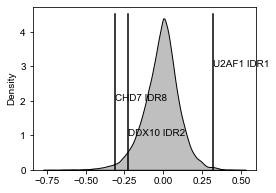

In [95]:
featidx1=myfeat.index('NCPR')
featidx2=myfeat.index('neg-neg')
plt.figure(figsize=(4,3))
sbn.kdeplot(ncpr,color='black',fill=True)

curridrs=['DDX10 IDR2','CHD7 IDR8','U2AF1 IDR1']
for i in range(0,len(curridrs)):
    tmpidx=mygenes.index(curridrs[i])
    print(myseqs[tmpidx])
    print(ncpr[tmpidx])
    print(zvecaa[tmpidx,featidx1])
    print(zvecaa[tmpidx,featidx2])
    plt.plot([ncpr[tmpidx],ncpr[tmpidx]],[0,4.5],'-k')
    plt.text(ncpr[tmpidx],i+1,curridrs[i])
#plt.xlim([-0.4,0.4])
#plt.savefig('../../Figures/2024_02/NARDINI+_schematic/ncpr_distribution.pdf', transparent=False, bbox_inches = "tight")

# Extract delta distributions for patterning

In [64]:
# Get patterning

import random
import numpy as np
import matplotlib.pyplot as plt
import localcider
from localcider.sequenceParameters import SequenceParameters

def get_kappa(seq,type1,type2):
    blobsz=[5]
    kappab=[]
    for b in blobsz:
        # Get full sequence asymmetry
        count1=0
        for res in type1: 
            count1=count1+myseq.count(res)
        
        count2=0    
        for res in type2: 
            count2=count2+myseq.count(res)
            
        sigAll=((count1/len(myseq))-(count2/len(myseq)))**2/((count1/len(myseq))+(count2/len(myseq)))
        
        # Get asymmetry for each blob
        sigX=[]
        for x in range(0,len(myseq)-b+1):
            subseq=seq[x:x+b]
            
            count1=0
            for res in type1:
                count1=count1+subseq.count(res)
                
            count2=0
            for res in type2:
                count2=count2+subseq.count(res)
            
            if count1+count2==0:
                sigX.append(0)
            else:
                sigX.append(((count1/b)-(count2/b))**2/((count1/b)+(count2/b)))
        
        asym=[]
        for x in range(0,len(sigX)):
            asym.append((sigX[x]-sigAll)**2)
        
        kappab.append(np.mean(asym))
   
    kappa=np.mean(kappab)
    return kappa 

    
def get_omega(seq,type1):
    blobsz=[5]
    omegab=[]
    for b in blobsz:
        # Get full sequence asymmetry
        count=0
        for res in type1: 
            count=count+myseq.count(res)
            
        sigAll=((count/len(myseq))-(1-(count/len(myseq))))**2
        
        # Get asymmetry for each blob
        sigX=[]
        for x in range(0,len(myseq)-b+1):
            count=0
            subseq=seq[x:x+b]
            for res in type1:
                count=count+subseq.count(res)
                
            sigX.append(((count/b)-(1-(count/b)))**2)
        
        asym=[]
        for x in range(0,len(sigX)):
            asym.append((sigX[x]-sigAll)**2)
        
        omegab.append(np.mean(asym))
   
    omega=np.mean(omegab)
    return omega   
                
        
        
def get_org_seq_vals(myseq,typeall,fracsall):
    
    org_seq_arr = np.zeros((len(typeall),len(typeall)))
    
    for count1 in range(0,len(typeall)):
        type1 = typeall[count1]

        for count2 in range(count1,len(typeall)):
            type2 = typeall[count2]

            if type1 == type2 and fracsall[count1]>0.10:
                org_seq_arr[count1, count2]=get_omega(myseq,type1)
                
            if type1 != type2 and fracsall[count1]>0.10 and fracsall[count2]>0.10:
                org_seq_arr[count1, count2]=get_kappa(myseq,type1,type2)
    
    org_seq_1d=org_seq_arr.reshape([1, len(typeall)**2])
    return org_seq_1d


def get_scramble_seqs_vals(myseq,num_seqs,typeall,fracsall):
    
    currseq=[]
    scr_vals=np.zeros((num_seqs,len(typeall)**2))
    
    for x in range(0,num_seqs):
        #print(x)
        currseq=''.join(random.sample(myseq,len(myseq)))
        
        scr_seq_arr = np.zeros((len(typeall),len(typeall)))
    
        for count1 in range(0,len(typeall)):
            type1 = typeall[count1]

            for count2 in range(count1,len(typeall)):
                type2 = typeall[count2]

                if type1 == type2 and fracsall[count1]>0.10:
                    scr_seq_arr[count1, count2]=get_omega(currseq,type1)

                if type1 != type2 and fracsall[count1]>0.10 and fracsall[count2]>0.10:
                    scr_seq_arr[count1, count2]=get_kappa(currseq,type1,type2)
        
        scr_vals[x,0:len(typeall)**2] = scr_seq_arr.reshape([1, len(typeall)**2])
        
    
    mval=np.mean(scr_vals, axis=0)
    sval=np.std(scr_vals, axis=0)
    return [mval,sval,scr_vals]
    

####### SCRIPT STARTS HERE ####### 


num_seqs=100000

pol=['S','T','N','Q','C','H']
hyd=['I','L','M','V']
pos=['R','K']
neg=['E','D']
aro=['F','W','Y']
ala=['A']
pro=['P']
gly=['G']

#typeall=[pol,hyd,pos,neg,aro,ala,pro,gly]
typeall=[neg]

zvec=np.zeros((1,int(len(typeall)+(len(typeall)*(len(typeall)-1))/2)))
zvecdb=np.zeros((1,len(typeall)**2))


curridrs=['DDX10 IDR2','CHD7 IDR8']
countseqs=-1
for i in range(0,len(curridrs)):
    tmpidx=mygenes.index(curridrs[i])
    myseq=myseqs[tmpidx]
    #print(myseq)
    fracsall=[]
    countseqs=countseqs+1
    for type1 in typeall:
        mycount=0
        for res in type1:
            mycount=mycount+myseq.count(res)
        fracsall.append(mycount/len(myseq))

    #print(countseqs)
    #print(fracsall)

    myarr=get_org_seq_vals(myseq,typeall,fracsall)

    [meanvals,stdvals,allvals]=get_scramble_seqs_vals(myseq,num_seqs,typeall,fracsall)

    #print(allvals)
    #print(len(allvals[:,0])
    print(myarr[0])
    print((myarr[0]-meanvals[0])/stdvals[0])
    
    tmpdf=pd.DataFrame()
    tmpdf['neg-neg']=allvals[:,0]
    #print(tmpdf)
    currname=curridrs[i].replace(' ','_')
    tmpdf.to_csv('data/'+currname+'_neg-neg_scrambles.csv')
    
    tmpdf=pd.DataFrame()
    tmpdf['neg-neg']=myarr[0]
    #print(tmpdf)
    currname=curridrs[i].replace(' ','_')
    tmpdf.to_csv('data/'+currname+'_neg-neg_wt_sequence.csv')


[0.34484628]
[5.56989509]
[0.04065683]
[-1.62954505]


## Load in delat distributions and plot

5.447796457620971


meta NOT subset; don't know how to subset; dropped


-1.6706621345692962


meta NOT subset; don't know how to subset; dropped


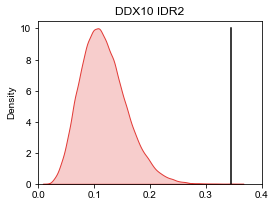

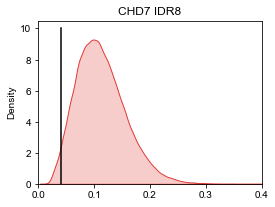

In [78]:
curridrs=['DDX10 IDR2','CHD7 IDR8']
for i in range(0,len(curridrs)):
    currname=curridrs[i].replace(' ','_')
    tmpdf=pd.read_csv('data/'+currname+'_neg-neg_scrambles.csv')
    scrambledeltas=tmpdf['neg-neg'].tolist()

    tmpdf=pd.read_csv('data/'+currname+'_neg-neg_wt_sequence.csv')
    wtdelta=tmpdf['neg-neg'].tolist()
    
    tmpidx=mygenes.index(curridrs[i])
    featidx=myfeat.index('neg-neg')
    print(zvecaa[tmpidx,featidx])
    
    plt.figure(figsize=(4,3))
    sbn.kdeplot(scrambledeltas,color='#e23a36',fill=True)
    plt.plot([wtdelta,wtdelta],[0,10],'-k')
    plt.title(curridrs[i])
    plt.ylim([0, 10.5])
    plt.xlim([0, 0.4])
    
    #plt.savefig('../../Figures/2024_02/NARDINI+_schematic/delta_neg-neg_'+currname+'.pdf', transparent=False, bbox_inches = "tight")

## Plot Figure 1H

    Unnamed: 0       Genes   Uniprot  Start Pos  End Pos  \
0            0   CHD7 IDR5  Q9P2D1_5       2157     2290   
1            1   CHD7 IDR6  Q9P2D1_6       2373     2404   
2            2   CHD7 IDR7  Q9P2D1_7       2820     2890   
3            3   CHD7 IDR8  Q9P2D1_8       2930     2997   
4            4  DDX10 IDR1  Q13206_1          0       48   
5            5  DDX10 IDR2  Q13206_2        559      634   
6            6  DDX10 IDR3  Q13206_3        696      858   
7            7   CHD7 IDR1  Q9P2D1_1         30      312   
8            8   CHD7 IDR2  Q9P2D1_2        347      820   
9            9   CHD7 IDR3  Q9P2D1_3       1570     1602   
10          10   CHD7 IDR4  Q9P2D1_4       1831     1901   

                                             Sequence   pol-pol   pol-hyd  \
0   SSAHIQDERVLEQAEGKVEEPENPAAKEKCEGKEEEEETDGSGKES...  0.277490  0.000000   
1                     ISGSEDITTSPQLSKEDALNLSVPRQRRRRR -0.193344 -0.964541   
2   SAATGNTTTASSQGEPEDSTSKGEEKGNENEDENKDSEKSTDAV

([<matplotlib.axis.XTick at 0x1508fa54dd90>,
 [Text(0.5, 0, 'Frac D+E'),
  Text(1.5, 0, 'Frac E'),
  Text(2.5, 0, 'Frac D'),
  Text(3.5, 0, 'E Patch'),
  Text(4.5, 0, 'FCR'),
  Text(5.5, 0, 'Frac L'),
  Text(6.5, 0, 'pol-gly'),
  Text(7.5, 0, 'Frac Chain Expanding'),
  Text(8.5, 0, 'Frac I'),
  Text(9.5, 0, 'Frac G'),
  Text(10.5, 0, 'gly-gly'),
  Text(11.5, 0, 'Frac N'),
  Text(12.5, 0, 'Frac Aliphatic'),
  Text(13.5, 0, 'Frac A'),
  Text(14.5, 0, 'E/D Ratio'),
  Text(15.5, 0, 'Disorder Promoting'),
  Text(16.5, 0, 'Frac F'),
  Text(17.5, 0, 'pos-neg'),
  Text(18.5, 0, 'pos-pos'),
  Text(19.5, 0, 'pol-pos'),
  Text(20.5, 0, 'Frac K'),
  Text(21.5, 0, 'pol-pol'),
  Text(22.5, 0, 'hyd-gly'),
  Text(23.5, 0, 'T Patch'),
  Text(24.5, 0, 'Q Patch'),
  Text(25.5, 0, 'D Patch'),
  Text(26.5, 0, 'Hydrophobicity'),
  Text(27.5, 0, 'R Patch'),
  Text(28.5, 0, 'K Patch'),
  Text(29.5, 0, 'G Patch'),
  Text(30.5, 0, 'A Patch'),
  Text(31.5, 0, 'hyd-hyd'),
  Text(32.5, 0, 'Frac S'),
  Text(33.5, 0

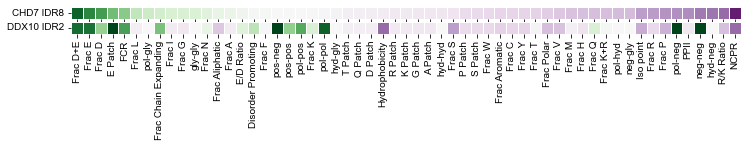

In [58]:
schemdf=pd.read_excel('data/schematic_patterning_compositional_feature_zscores.xlsx')
print(schemdf)

genenamesIDRnum_sub=schemdf['Genes'].tolist()
myfullfeats=schemdf.columns[6:]

fdf=schemdf[myfullfeats]
stdvals_features_all=[]
for i in range(0,len(myfullfeats)):
    stdvals_features_all.append(np.std(fdf[myfullfeats[i]].tolist()))

# Remove features that aren't different between the IDRs
indices=[i for i, ltr in enumerate(stdvals_features_all) if ltr > 3e-17]
myfeats=[]
for i in indices:
    myfeats.append(myfullfeats[i])
    
print(len(myfeats))


sublist=['CHD7 IDR8','DDX10 IDR2']

tmpidx=[]
tmpgenes=[]
for s in sublist:
    tmpidx.append(genenamesIDRnum_sub.index(s))
    tmpgenes.append(genenamesIDRnum_sub[genenamesIDRnum_sub.index(s)])
    print(genenamesIDRnum_sub[genenamesIDRnum_sub.index(s)])

dffeature = pd.DataFrame(myfeats,columns =['Sequence Features'])
dftmp=pd.DataFrame()
for s in range(0,len(tmpgenes)):
    tdf=schemdf[schemdf['Genes']==tmpgenes[s]]
    dftmp[tmpgenes[s]]=tdf[myfeats].to_numpy()[0]
    
print(dftmp)
dfr = pd.concat([dffeature, dftmp], axis=1)

## Only save features that at least one idr has a z-score > 0 ##
#tmp=(abs(dfr.select_dtypes(include=['number'])) > 1).any(1)
tmp=(dfr.select_dtypes(include=['number']) != 0).any(1)
dfr= dfr.loc[tmp==True]
print(dfr.head(20))


final_dfr = dfr.sort_values(by=[sublist[0]], ascending=False) # sorting by the first gene in your sublist
#final_dfr = dfr
print(final_dfr)
print(len(final_dfr))

final_dfr2=final_dfr;
mygroup=final_dfr2.pop('Sequence Features')


if len(sublist)>1:
    f,axs = plt.subplots(len(sublist),1,sharex=True,figsize = (12, len(sublist)/4))
    for i in range(0,len(sublist)):
        sbn.heatmap(final_dfr2[[sublist[i]]].T,cmap="PRGn",cbar=False,ax=axs[i],vmin=-3,vmax=3,square=True,linewidth=0.5)
        axs[i].tick_params(labelrotation=0)
else:
    f,ax1 = plt.subplots(1,1,sharex=True,figsize = (12, 1))
    g1 = sbn.heatmap(final_dfr2[[sublist[0]]].T,cmap="PRGn",cbar=False,ax=ax1,vmin=-3,vmax=3,square=True,linewidth=0.5)

plt.xticks(np.arange(0.5, len(mygroup), 1), mygroup,rotation=90)